# ESP32-S3 Edge AI Smart Home Security System

## AI Pipeline

PIR Motion Detection
→ Human Verification
→ Human Activity Classification
→ Face Recognition
→ Owner / Unknown
→ Security Alert

### Target Hardware
ESP32-S3 with 8 MB PSRAM

### Deployment Requirements
- TensorFlow Lite Micro
- INT8 Quantization
- ESP32-S3 compatible operators
- No unsupported 5-D inference operations
- 96 × 96 input resolution

In [ ]:
!pip -q install tensorflow==2.20.0
!pip -q install opencv-python
!pip -q install scikit-learn
!pip -q install matplotlib
!pip -q install pandas

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

print("======================================")
print("ESP32-S3 EDGE AI ENVIRONMENT")
print("======================================")

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("OpenCV version:", cv2.__version__)

print()
print("GPU devices:")
print(tf.config.list_physical_devices('GPU'))

print()
print("Environment check completed.")

ESP32-S3 EDGE AI ENVIRONMENT
TensorFlow version: 2.20.0
NumPy version: 2.1.3
OpenCV version: 5.0.0

GPU devices:
[]

Environment check completed.


In [ ]:
from google.colab import files

print("Select your 16 video clips.")
print("You can select all 16 at once.")

uploaded = files.upload()

print()
print("======================================")
print("UPLOAD COMPLETE")
print("======================================")
print("Number of files uploaded:", len(uploaded))

for filename in uploaded.keys():
    print(filename)

Select your 16 video clips.
You can select all 16 at once.


Saving human_01.mp4 to human_01.mp4
Saving human_02.mp4 to human_02.mp4
Saving human_03.mp4 to human_03.mp4
Saving human_04.mp4 to human_04.mp4
Saving human_05.mp4 to human_05.mp4
Saving human_06.mp4 to human_06.mp4
Saving human_07.mp4 to human_07.mp4
Saving human_08.mp4 to human_08.mp4
Saving nonhuman_01.mp4 to nonhuman_01.mp4
Saving nonhuman_02.mp4 to nonhuman_02.mp4
Saving nonhuman_03.mp4 to nonhuman_03.mp4
Saving nonhuman_04.mp4 to nonhuman_04.mp4
Saving nonhuman_05.mp4 to nonhuman_05.mp4
Saving nonhuman_06.mp4 to nonhuman_06.mp4
Saving nonhuman_07.mp4 to nonhuman_07.mp4
Saving nonhuman_08.mp4 to nonhuman_08.mp4

UPLOAD COMPLETE
Number of files uploaded: 16
human_01.mp4
human_02.mp4
human_03.mp4
human_04.mp4
human_05.mp4
human_06.mp4
human_07.mp4
human_08.mp4
nonhuman_01.mp4
nonhuman_02.mp4
nonhuman_03.mp4
nonhuman_04.mp4
nonhuman_05.mp4
nonhuman_06.mp4
nonhuman_07.mp4
nonhuman_08.mp4


In [ ]:
import os
import shutil
import cv2
import glob

# ==========================================
# STEP 2D
# ORGANIZE VIDEOS + EXTRACT FRAMES
# ==========================================

BASE = "/content/edge_ai_project"

# Video folders
HUMAN_VIDEOS = os.path.join(BASE, "human_videos")
NONHUMAN_VIDEOS = os.path.join(BASE, "nonhuman_videos")

# Dataset folders
HUMAN_IMAGES = os.path.join(BASE, "dataset", "human")
NONHUMAN_IMAGES = os.path.join(BASE, "dataset", "non_human")

# Create folders
for folder in [
    HUMAN_VIDEOS,
    NONHUMAN_VIDEOS,
    HUMAN_IMAGES,
    NONHUMAN_IMAGES
]:
    os.makedirs(folder, exist_ok=True)


# ==========================================
# 1. ORGANIZE THE 16 UPLOADED VIDEOS
# ==========================================

for filename in os.listdir("/content"):

    if filename.lower().endswith(".mp4"):

        source = os.path.join("/content", filename)

        if filename.lower().startswith("human_"):
            destination = os.path.join(
                HUMAN_VIDEOS,
                filename
            )

        elif filename.lower().startswith("nonhuman_"):
            destination = os.path.join(
                NONHUMAN_VIDEOS,
                filename
            )

        else:
            continue

        shutil.move(source, destination)


print("======================================")
print("VIDEO ORGANIZATION")
print("======================================")

print("Human videos:",
      len(os.listdir(HUMAN_VIDEOS)))

print("Non-human videos:",
      len(os.listdir(NONHUMAN_VIDEOS)))


# ==========================================
# 2. FRAME EXTRACTION FUNCTION
# ==========================================

def extract_frames(video_folder,
                   output_folder,
                   prefix,
                   frame_interval=5):

    videos = sorted(
        glob.glob(
            os.path.join(video_folder, "*.mp4")
        )
    )

    total_frames = 0

    for video_path in videos:

        cap = cv2.VideoCapture(video_path)

        frame_number = 0

        video_name = os.path.splitext(
            os.path.basename(video_path)
        )[0]

        while True:

            ret, frame = cap.read()

            if not ret:
                break

            # Save every 5th frame
            if frame_number % frame_interval == 0:

                filename = (
                    f"{prefix}_{video_name}_"
                    f"{frame_number:06d}.jpg"
                )

                output_path = os.path.join(
                    output_folder,
                    filename
                )

                cv2.imwrite(
                    output_path,
                    frame
                )

                total_frames += 1

            frame_number += 1

        cap.release()

    return total_frames


# ==========================================
# 3. EXTRACT HUMAN FRAMES
# ==========================================

human_count = extract_frames(
    HUMAN_VIDEOS,
    HUMAN_IMAGES,
    "human",
    frame_interval=5
)


# ==========================================
# 4. EXTRACT NON-HUMAN FRAMES
# ==========================================

nonhuman_count = extract_frames(
    NONHUMAN_VIDEOS,
    NONHUMAN_IMAGES,
    "nonhuman",
    frame_interval=5
)


# ==========================================
# FINAL RESULT
# ==========================================

print()
print("======================================")
print("FRAME EXTRACTION COMPLETE")
print("======================================")

print("Human images:", human_count)
print("Non-human images:", nonhuman_count)

print()
print("Dataset location:")
print(BASE + "/dataset/")

VIDEO ORGANIZATION
Human videos: 8
Non-human videos: 8

FRAME EXTRACTION COMPLETE
Human images: 869
Non-human images: 818

Dataset location:
/content/edge_ai_project/dataset/


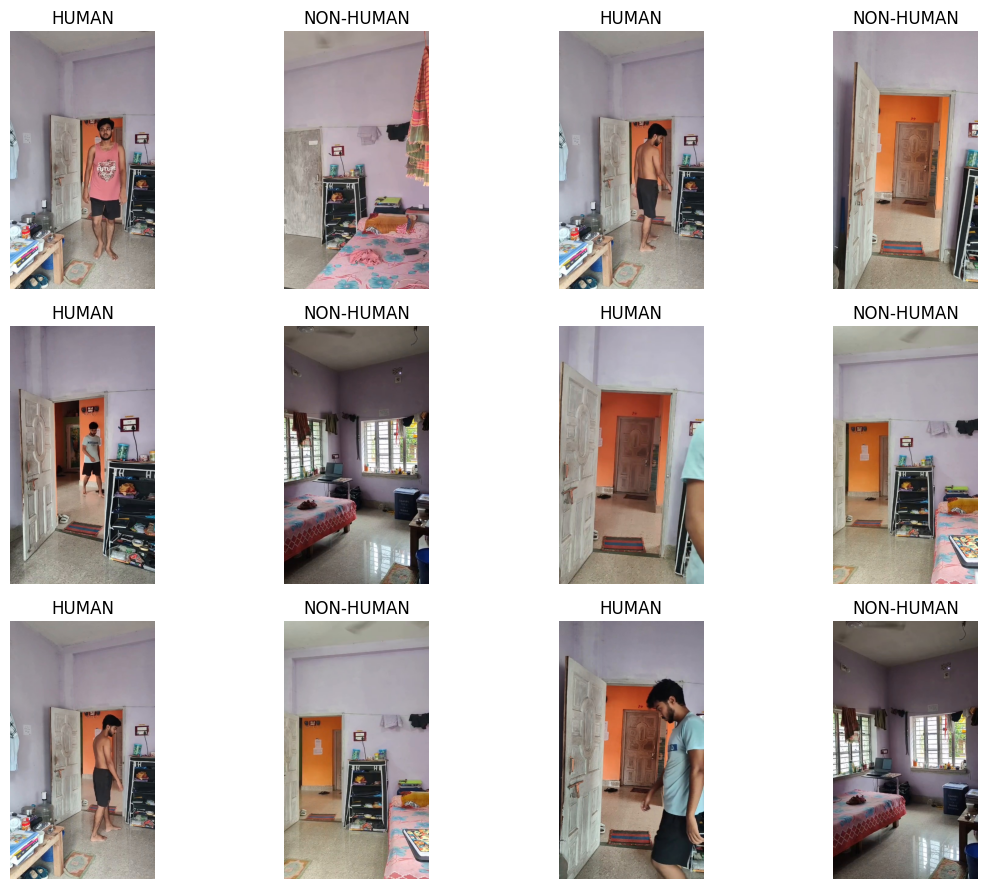

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

human_dir = "/content/edge_ai_project/dataset/human"
nonhuman_dir = "/content/edge_ai_project/dataset/non_human"

human_files = [
    os.path.join(human_dir, f)
    for f in os.listdir(human_dir)
    if f.lower().endswith(".jpg")
]

nonhuman_files = [
    os.path.join(nonhuman_dir, f)
    for f in os.listdir(nonhuman_dir)
    if f.lower().endswith(".jpg")
]

# Select 6 random samples from each class
random.seed(42)

human_samples = random.sample(human_files, 6)
nonhuman_samples = random.sample(nonhuman_files, 6)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

# Human images
for i, path in enumerate(human_samples):
    img = Image.open(path)

    ax = axes[i // 2, (i % 2) * 2]
    ax.imshow(img)
    ax.set_title("HUMAN")
    ax.axis("off")

# Non-human images
for i, path in enumerate(nonhuman_samples):
    img = Image.open(path)

    ax = axes[i // 2, (i % 2) * 2 + 1]
    ax.imshow(img)
    ax.set_title("NON-HUMAN")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
import glob
import re

BASE = "/content/edge_ai_project"

SOURCE_HUMAN = os.path.join(BASE, "dataset", "human")
SOURCE_NONHUMAN = os.path.join(BASE, "dataset", "non_human")

SPLIT_BASE = os.path.join(BASE, "dataset_split")

# Remove previous split if it exists
if os.path.exists(SPLIT_BASE):
    shutil.rmtree(SPLIT_BASE)

# Create folders
for split in ["train", "validation", "test"]:
    for label in ["human", "non_human"]:
        os.makedirs(
            os.path.join(SPLIT_BASE, split, label),
            exist_ok=True
        )


# ------------------------------------------------
# Function to identify video number from filename
# ------------------------------------------------

def get_video_number(filename, prefix):

    # Example:
    # human_human_01_000025.jpg
    # nonhuman_nonhuman_01_000025.jpg

    match = re.search(
        rf"{prefix}_(?:{prefix}_)?(\d+)_",
        filename.lower()
    )

    if match:
        return int(match.group(1))

    return None


# ------------------------------------------------
# Split each class by VIDEO
# ------------------------------------------------

def split_class(source_dir, label, prefix):

    files = sorted(
        glob.glob(os.path.join(source_dir, "*.jpg"))
    )

    video_groups = {}

    for file_path in files:

        filename = os.path.basename(file_path)

        video_number = get_video_number(
            filename,
            prefix
        )

        if video_number is None:
            print("Could not identify:", filename)
            continue

        video_groups.setdefault(
            video_number, []
        ).append(file_path)

    video_numbers = sorted(video_groups.keys())

    print(f"\n{label.upper()} videos found:")
    print(video_numbers)

    if len(video_numbers) != 8:
        print(
            "WARNING: Expected 8 videos, "
            f"but found {len(video_numbers)}"
        )

    # First 6 → train
    train_videos = video_numbers[:6]

    # 7th → validation
    validation_videos = video_numbers[6:7]

    # 8th → test
    test_videos = video_numbers[7:8]

    split_map = {
        "train": train_videos,
        "validation": validation_videos,
        "test": test_videos
    }

    counts = {}

    for split, videos in split_map.items():

        count = 0

        for video_number in videos:

            for source_file in video_groups[
                video_number
            ]:

                destination = os.path.join(
                    SPLIT_BASE,
                    split,
                    label,
                    os.path.basename(source_file)
                )

                shutil.copy2(
                    source_file,
                    destination
                )

                count += 1

        counts[split] = count

    return video_numbers, counts


# ------------------------------------------------
# Perform split
# ------------------------------------------------

human_videos, human_counts = split_class(
    SOURCE_HUMAN,
    "human",
    "human"
)

nonhuman_videos, nonhuman_counts = split_class(
    SOURCE_NONHUMAN,
    "non_human",
    "nonhuman"
)


# ------------------------------------------------
# Display final split
# ------------------------------------------------

print()
print("======================================")
print("VIDEO-LEVEL DATASET SPLIT COMPLETE")
print("======================================")

print("\nHUMAN")
print("Training videos:", human_videos[:6])
print("Validation video:", human_videos[6:7])
print("Test video:", human_videos[7:8])

print("\nNON-HUMAN")
print("Training videos:", nonhuman_videos[:6])
print("Validation video:", nonhuman_videos[6:7])
print("Test video:", nonhuman_videos[7:8])

print("\n--------------------------------------")
print("IMAGE COUNTS")
print("--------------------------------------")

print("Human:")
print("  Train:", human_counts["train"])
print("  Validation:", human_counts["validation"])
print("  Test:", human_counts["test"])

print("\nNon-human:")
print("  Train:", nonhuman_counts["train"])
print("  Validation:", nonhuman_counts["validation"])
print("  Test:", nonhuman_counts["test"])


HUMAN videos found:
[1, 2, 3, 4, 5, 6, 7, 8]

NON_HUMAN videos found:
[1, 2, 3, 4, 5, 6, 7, 8]

VIDEO-LEVEL DATASET SPLIT COMPLETE

HUMAN
Training videos: [1, 2, 3, 4, 5, 6]
Validation video: [7]
Test video: [8]

NON-HUMAN
Training videos: [1, 2, 3, 4, 5, 6]
Validation video: [7]
Test video: [8]

--------------------------------------
IMAGE COUNTS
--------------------------------------
Human:
  Train: 579
  Validation: 161
  Test: 129

Non-human:
  Train: 625
  Validation: 98
  Test: 95


In [ ]:
import tensorflow as tf
import os

# ==========================================
# STEP 5
# CREATE 96x96 RGB DATASETS
# ==========================================

BASE = "/content/edge_ai_project"
SPLIT_BASE = os.path.join(BASE, "dataset_split")

IMG_SIZE = (96, 96)
BATCH_SIZE = 32
SEED = 42

# ------------------------------------------
# Training dataset
# ------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_BASE, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# ------------------------------------------
# Validation dataset
# ------------------------------------------

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_BASE, "validation"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------
# Test dataset
# ------------------------------------------

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_BASE, "test"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print()
print("======================================")
print("DATASET PREPARATION COMPLETE")
print("======================================")

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

print()
print("Class names:")
print(train_ds.class_names)

print()
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 1204 files belonging to 2 classes.
Found 259 files belonging to 2 classes.
Found 224 files belonging to 2 classes.

DATASET PREPARATION COMPLETE
Image size: (96, 96)
Batch size: 32

Class names:
['human', 'non_human']

Training batches: 38
Validation batches: 9
Test batches: 7


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# STEP 6
# ESP32-S3 FRIENDLY CNN
# ==========================================

IMG_HEIGHT = 96
IMG_WIDTH = 96
IMG_CHANNELS = 3

model = models.Sequential([

    # Input
    layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
        name="image_input"
    ),

    # Block 1
    layers.Conv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv1"
    ),
    layers.MaxPooling2D(
        (2, 2),
        name="pool1"
    ),

    # Block 2
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv2"
    ),
    layers.MaxPooling2D(
        (2, 2),
        name="pool2"
    ),

    # Block 3
    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv3"
    ),
    layers.MaxPooling2D(
        (2, 2),
        name="pool3"
    ),

    # Feature reduction
    layers.GlobalAveragePooling2D(
        name="global_average_pool"
    ),

    # Classification
    layers.Dense(
        32,
        activation="relu",
        name="dense1"
    ),

    layers.Dense(
        1,
        activation="sigmoid",
        name="output"
    )
])

print("======================================")
print("ESP32-S3 CNN CREATED")
print("======================================")

model.summary()

print()
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

print()
print("Total parameters:", model.count_params())

ESP32-S3 CNN CREATED


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)


Input shape: (None, 96, 96, 3)
Output shape: (None, 1)

Total parameters: 25697


In [ ]:
import tensorflow as tf
import time

# ==========================================
# STEP 7
# COMPILE AND TRAIN HUMAN DETECTION MODEL
# ==========================================

# Normalize images from 0-255 to 0-1
def normalize_images(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels


train_normalized = train_ds.map(
    normalize_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_normalized = val_ds.map(
    normalize_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_normalized = test_ds.map(
    normalize_images,
    num_parallel_calls=tf.data.AUTOTUNE
)


# Improve pipeline speed
train_normalized = train_normalized.prefetch(
    tf.data.AUTOTUNE
)

val_normalized = val_normalized.prefetch(
    tf.data.AUTOTUNE
)

test_normalized = test_normalized.prefetch(
    tf.data.AUTOTUNE
)


# ------------------------------------------
# Compile
# ------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)


# ------------------------------------------
# Training callbacks
# ------------------------------------------

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]


# ------------------------------------------
# Train
# ------------------------------------------

print("======================================")
print("STARTING HUMAN DETECTION TRAINING")
print("======================================")

start_time = time.time()

history = model.fit(
    train_normalized,
    validation_data=val_normalized,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print()
print("======================================")
print("TRAINING COMPLETE")
print("======================================")
print(
    "Training time: "
    f"{training_time / 60:.2f} minutes"
)

STARTING HUMAN DETECTION TRAINING
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 400ms/step - accuracy: 0.4975 - loss: 0.6963 - precision: 0.5168 - recall: 0.4928 - val_accuracy: 0.3784 - val_loss: 0.7252 - val_precision: 0.3784 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 389ms/step - accuracy: 0.5000 - loss: 0.6932 - precision: 0.5112 - recall: 0.8400 - val_accuracy: 0.3784 - val_loss: 0.7104 - val_precision: 0.3784 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 389ms/step - accuracy: 0.5174 - loss: 0.6910 - precision: 0.5236 - recall: 0.7808 - val_accuracy: 0.3784 - val_loss: 0.7105 - val_precision: 0.3784 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 390ms/step - accuracy: 0.5548 - loss: 0.6847 - precision: 0.5529 - recall: 0.7440 - val_accuracy: 0.6023 - val_loss: 0.6710 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/25
38/38 ━

MODEL EVALUATION

VALIDATION RESULTS
------------------
loss: 0.6613
compile_metrics: 0.5598

TEST RESULTS
------------
loss: 0.4555
compile_metrics: 1.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       HUMAN     1.0000    1.0000    1.0000       129
   NON-HUMAN     1.0000    1.0000    1.0000        95

    accuracy                         1.0000       224
   macro avg     1.0000    1.0000    1.0000       224
weighted avg     1.0000    1.0000    1.0000       224


CONFUSION MATRIX
[[129   0]
 [  0  95]]


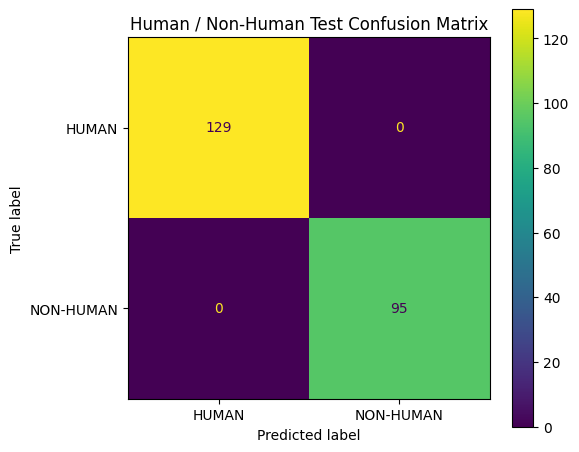

In [ ]:
# ==========================================
# STEP 8
# FINAL HUMAN / NON-HUMAN MODEL EVALUATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("======================================")
print("MODEL EVALUATION")
print("======================================")

# ------------------------------------------
# 1. Evaluate on validation set
# ------------------------------------------

val_results = model.evaluate(
    val_normalized,
    verbose=0
)

print("\nVALIDATION RESULTS")
print("------------------")
for name, value in zip(model.metrics_names, val_results):
    print(f"{name}: {value:.4f}")


# ------------------------------------------
# 2. Evaluate on completely unseen test set
# ------------------------------------------

test_results = model.evaluate(
    test_normalized,
    verbose=0
)

print("\nTEST RESULTS")
print("------------")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")


# ------------------------------------------
# 3. Generate predictions
# ------------------------------------------

y_true = []
y_pred = []

for images, labels in test_normalized:

    predictions = model.predict(
        images,
        verbose=0
    )

    predictions = predictions.ravel()

    predicted_classes = (
        predictions >= 0.5
    ).astype(int)

    y_true.extend(
        labels.numpy().astype(int).ravel()
    )

    y_pred.extend(
        predicted_classes
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ------------------------------------------
# 4. Classification report
# ------------------------------------------

print("\n======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "HUMAN",
            "NON-HUMAN"
        ],
        digits=4
    )
)


# ------------------------------------------
# 5. Confusion matrix
# ------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n======================================")
print("CONFUSION MATRIX")
print("======================================")

print(cm)


# ------------------------------------------
# 6. Display confusion matrix
# ------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "HUMAN",
        "NON-HUMAN"
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "Human / Non-Human Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

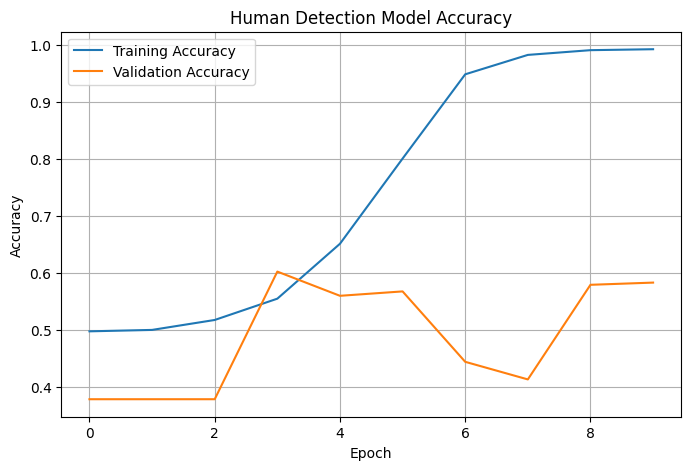

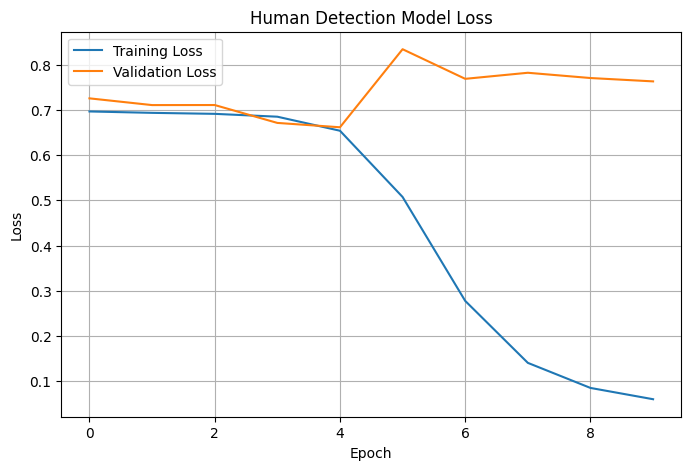

In [ ]:
# ==========================================
# STEP 8B
# TRAINING PERFORMANCE GRAPHS
# ==========================================

history_dict = history.history

plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_dict["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Human Detection Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["loss"],
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Human Detection Model Loss")
plt.legend()
plt.grid(True)
plt.show()

VALIDATION CLASSIFICATION REPORT
              precision    recall  f1-score   support

       HUMAN     0.5967    0.9006    0.7178       161
   NON-HUMAN     0.0000    0.0000    0.0000        98

    accuracy                         0.5598       259
   macro avg     0.2984    0.4503    0.3589       259
weighted avg     0.3709    0.5598    0.4462       259

Validation confusion matrix:
[[145  16]
 [ 98   0]]


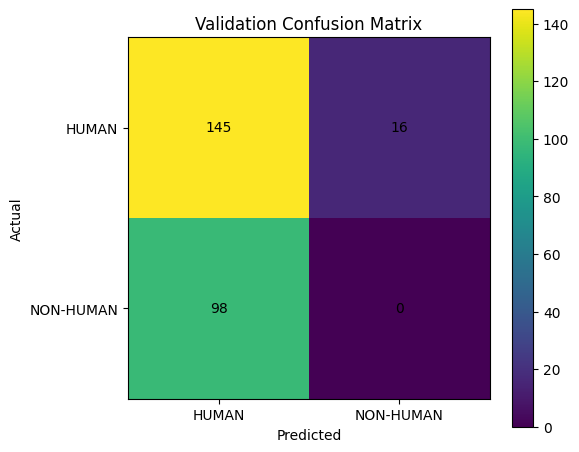

In [ ]:
# ==========================================
# STEP 8C
# VALIDATION CONFUSION MATRIX
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_val_true = []
y_val_pred = []

for images, labels in val_normalized:

    predictions = model.predict(
        images,
        verbose=0
    ).ravel()

    predicted_classes = (
        predictions >= 0.5
    ).astype(int)

    y_val_true.extend(
        labels.numpy().astype(int).ravel()
    )

    y_val_pred.extend(predicted_classes)

y_val_true = np.array(y_val_true)
y_val_pred = np.array(y_val_pred)

print("======================================")
print("VALIDATION CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=[
            "HUMAN",
            "NON-HUMAN"
        ],
        digits=4
    )
)

cm_val = confusion_matrix(
    y_val_true,
    y_val_pred
)

print("Validation confusion matrix:")
print(cm_val)

plt.figure(figsize=(6, 5))

plt.imshow(cm_val)

plt.xticks(
    [0, 1],
    ["HUMAN", "NON-HUMAN"]
)

plt.yticks(
    [0, 1],
    ["HUMAN", "NON-HUMAN"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_val[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

VALIDATION MISCLASSIFICATIONS
Wrong predictions: 258
Total validation images: 259


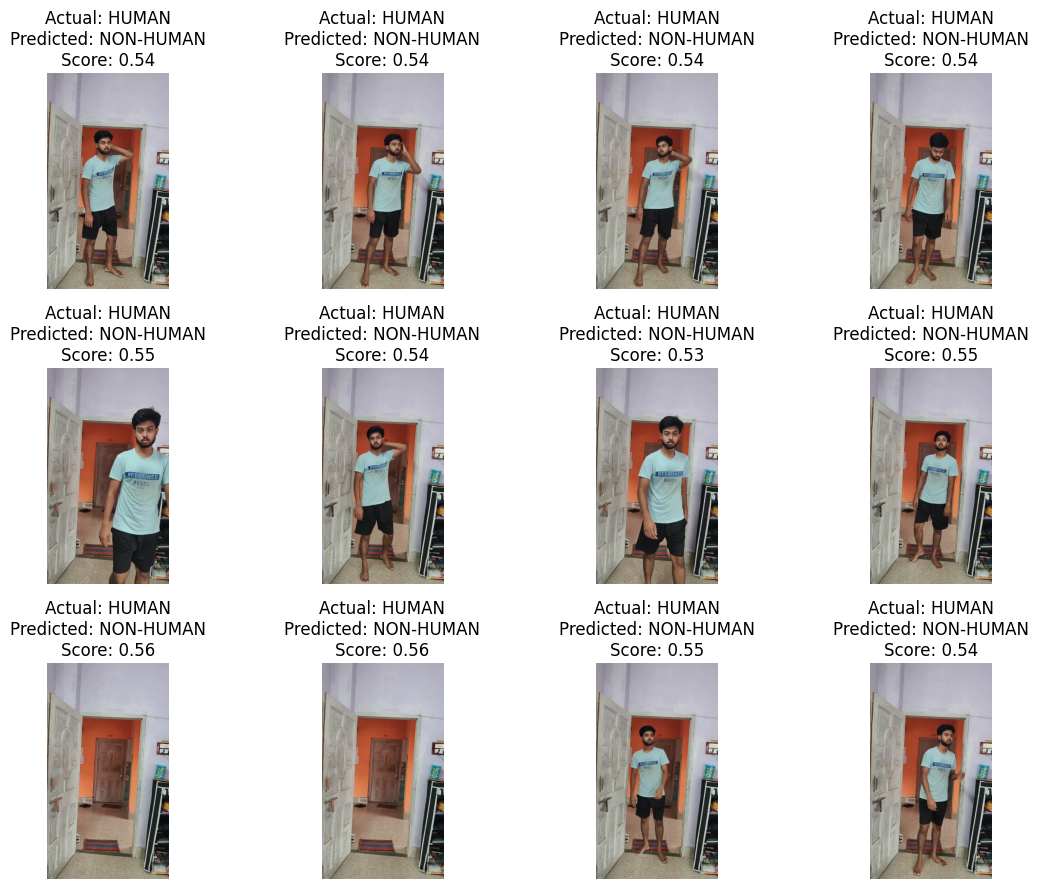

In [ ]:
# ==========================================
# STEP 8D
# SHOW VALIDATION MISCLASSIFICATIONS
# ==========================================

import os
import glob
import math
from PIL import Image

val_human_dir = os.path.join(
    SPLIT_BASE,
    "validation",
    "human"
)

val_nonhuman_dir = os.path.join(
    SPLIT_BASE,
    "validation",
    "non_human"
)

val_files = []

for label, folder in [
    (0, val_human_dir),
    (1, val_nonhuman_dir)
]:
    for f in glob.glob(
        os.path.join(folder, "*.jpg")
    ):
        val_files.append((f, label))

wrong = []

for path, true_label in val_files:

    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype("float32") / 255.0

    prediction = model.predict(
        np.expand_dims(arr, axis=0),
        verbose=0
    )[0][0]

    predicted_label = int(prediction >= 0.5)

    if predicted_label != true_label:
        wrong.append(
            (path, true_label, prediction)
        )

print("======================================")
print("VALIDATION MISCLASSIFICATIONS")
print("======================================")
print("Wrong predictions:", len(wrong))
print("Total validation images:", len(val_files))

# Show up to 12 incorrect examples
show_count = min(12, len(wrong))

if show_count > 0:

    fig, axes = plt.subplots(
        3, 4,
        figsize=(12, 9)
    )

    axes = axes.flatten()

    for i in range(show_count):

        path, true_label, prediction = wrong[i]

        img = Image.open(path)

        axes[i].imshow(img)

        true_name = (
            "HUMAN"
            if true_label == 0
            else "NON-HUMAN"
        )

        predicted_label = int(
            prediction >= 0.5
        )

        pred_name = (
            "HUMAN"
            if predicted_label == 0
            else "NON-HUMAN"
        )

        axes[i].set_title(
            f"Actual: {true_name}\n"
            f"Predicted: {pred_name}\n"
            f"Score: {prediction:.2f}"
        )

        axes[i].axis("off")

    for i in range(show_count, 12):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No validation errors found.")

In [ ]:
# ==========================================
# STEP 8E
# ROBUST VALIDATION CHECK
# ==========================================

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("======================================")
print("ROBUST VALIDATION CHECK")
print("======================================")

# Collect validation images and labels
all_images = []
all_labels = []

for images, labels in val_normalized:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

X_val = np.concatenate(all_images, axis=0)
y_val = np.concatenate(all_labels, axis=0).reshape(-1).astype(int)

print("Validation images:", len(y_val))
print("Human labels:", np.sum(y_val == 0))
print("Non-human labels:", np.sum(y_val == 1))

# Predict everything at once
scores = model.predict(
    X_val,
    verbose=0
).reshape(-1)

# IMPORTANT:
# 0 = HUMAN
# 1 = NON-HUMAN

y_pred = (scores >= 0.5).astype(int)

# Accuracy
accuracy = np.mean(y_pred == y_val)

print()
print("Manual validation accuracy:",
      f"{accuracy * 100:.2f}%")

print()
print("Prediction distribution:")
print("Predicted HUMAN:",
      np.sum(y_pred == 0))
print("Predicted NON-HUMAN:",
      np.sum(y_pred == 1))

# Confusion matrix
cm = confusion_matrix(
    y_val,
    y_pred
)

print()
print("======================================")
print("VALIDATION CONFUSION MATRIX")
print("======================================")

print(cm)

print()
print("======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_val,
        y_pred,
        target_names=[
            "HUMAN",
            "NON-HUMAN"
        ],
        digits=4
    )
)

ROBUST VALIDATION CHECK
Validation images: 259
Human labels: 161
Non-human labels: 98

Manual validation accuracy: 55.98%

Prediction distribution:
Predicted HUMAN: 243
Predicted NON-HUMAN: 16

VALIDATION CONFUSION MATRIX
[[145  16]
 [ 98   0]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       HUMAN     0.5967    0.9006    0.7178       161
   NON-HUMAN     0.0000    0.0000    0.0000        98

    accuracy                         0.5598       259
   macro avg     0.2984    0.4503    0.3589       259
weighted avg     0.3709    0.5598    0.4462       259



In [ ]:
# ==========================================
# STEP 9A
# IMPROVED VIDEO-LEVEL DATASET SPLIT
# ==========================================

import os
import shutil
import glob
import re
import random

BASE = "/content/edge_ai_project"

SOURCE_HUMAN = os.path.join(
    BASE, "dataset", "human"
)

SOURCE_NONHUMAN = os.path.join(
    BASE, "dataset", "non_human"
)

SPLIT_BASE = os.path.join(
    BASE, "dataset_split_v2"
)

# Remove previous version if present
if os.path.exists(SPLIT_BASE):
    shutil.rmtree(SPLIT_BASE)

# Create folders
for split in ["train", "validation", "test"]:
    for label in ["human", "non_human"]:
        os.makedirs(
            os.path.join(
                SPLIT_BASE,
                split,
                label
            ),
            exist_ok=True
        )


# ------------------------------------------
# Extract video number from filename
# ------------------------------------------

def get_video_number(filename, prefix):

    match = re.search(
        rf"{prefix}_(?:{prefix}_)?(\d+)_",
        filename.lower()
    )

    if match:
        return int(match.group(1))

    return None


# ------------------------------------------
# Get frames grouped by source video
# ------------------------------------------

def get_video_groups(source_dir, prefix):

    groups = {}

    files = glob.glob(
        os.path.join(source_dir, "*.jpg")
    )

    for file_path in files:

        filename = os.path.basename(file_path)

        number = get_video_number(
            filename,
            prefix
        )

        if number is not None:
            groups.setdefault(
                number, []
            ).append(file_path)

    return groups


# ------------------------------------------
# Split one class
# ------------------------------------------

def create_split(
    source_dir,
    label,
    prefix,
    seed=42
):

    groups = get_video_groups(
        source_dir,
        prefix
    )

    video_numbers = sorted(groups.keys())

    random.Random(seed).shuffle(
        video_numbers
    )

    train_videos = video_numbers[:5]
    val_videos = video_numbers[5:7]
    test_videos = video_numbers[7:8]

    split_map = {
        "train": train_videos,
        "validation": val_videos,
        "test": test_videos
    }

    counts = {}

    for split, videos in split_map.items():

        count = 0

        for video_number in videos:

            for source_file in groups[
                video_number
            ]:

                destination = os.path.join(
                    SPLIT_BASE,
                    split,
                    label,
                    os.path.basename(source_file)
                )

                shutil.copy2(
                    source_file,
                    destination
                )

                count += 1

        counts[split] = count

    return video_numbers, split_map, counts


# ------------------------------------------
# Create HUMAN split
# ------------------------------------------

human_order, human_split, human_counts = create_split(
    SOURCE_HUMAN,
    "human",
    "human",
    seed=42
)


# ------------------------------------------
# Create NON-HUMAN split
# ------------------------------------------

nonhuman_order, nonhuman_split, nonhuman_counts = create_split(
    SOURCE_NONHUMAN,
    "non_human",
    "nonhuman",
    seed=42
)


# ------------------------------------------
# Display result
# ------------------------------------------

print("======================================")
print("IMPROVED DATASET SPLIT")
print("======================================")

print("\nHUMAN")
print("Train videos:", human_split["train"])
print("Validation videos:", human_split["validation"])
print("Test video:", human_split["test"])

print("\nNON-HUMAN")
print("Train videos:", nonhuman_split["train"])
print("Validation videos:", nonhuman_split["validation"])
print("Test video:", nonhuman_split["test"])

print("\n--------------------------------------")
print("IMAGE COUNTS")
print("--------------------------------------")

print("\nHUMAN")
print("Train:", human_counts["train"])
print("Validation:", human_counts["validation"])
print("Test:", human_counts["test"])

print("\nNON-HUMAN")
print("Train:", nonhuman_counts["train"])
print("Validation:", nonhuman_counts["validation"])
print("Test:", nonhuman_counts["test"])

IMPROVED DATASET SPLIT

HUMAN
Train videos: [4, 5, 7, 8, 3]
Validation videos: [6, 1]
Test video: [2]

NON-HUMAN
Train videos: [4, 5, 7, 8, 3]
Validation videos: [6, 1]
Test video: [2]

--------------------------------------
IMAGE COUNTS
--------------------------------------

HUMAN
Train: 500
Validation: 295
Test: 74

NON-HUMAN
Train: 513
Validation: 200
Test: 105


In [ ]:
import tensorflow as tf
import os

IMG_SIZE = (96, 96)
BATCH_SIZE = 32
SEED = 42

# ------------------------------------------
# Training
# ------------------------------------------

train_ds_v2 = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_BASE, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# ------------------------------------------
# Validation
# ------------------------------------------

val_ds_v2 = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_BASE, "validation"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------
# Test
# ------------------------------------------

test_ds_v2 = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_BASE, "test"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ------------------------------------------
# Normalize
# ------------------------------------------

def normalize_images_v2(images, labels):

    images = tf.cast(
        images,
        tf.float32
    ) / 255.0

    return images, labels


train_normalized_v2 = train_ds_v2.map(
    normalize_images_v2,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_normalized_v2 = val_ds_v2.map(
    normalize_images_v2,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_normalized_v2 = test_ds_v2.map(
    normalize_images_v2,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_normalized_v2 = train_normalized_v2.prefetch(
    tf.data.AUTOTUNE
)

val_normalized_v2 = val_normalized_v2.prefetch(
    tf.data.AUTOTUNE
)

test_normalized_v2 = test_normalized_v2.prefetch(
    tf.data.AUTOTUNE
)

print("======================================")
print("V2 DATASETS READY")
print("======================================")

print("Classes:", train_ds_v2.class_names)

print(
    "Train batches:",
    tf.data.experimental.cardinality(
        train_normalized_v2
    ).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(
        val_normalized_v2
    ).numpy()
)

print(
    "Test batches:",
    tf.data.experimental.cardinality(
        test_normalized_v2
    ).numpy()
)

Found 1013 files belonging to 2 classes.
Found 495 files belonging to 2 classes.
Found 179 files belonging to 2 classes.
V2 DATASETS READY
Classes: ['human', 'non_human']
Train batches: 32
Validation batches: 16
Test batches: 6


In [ ]:
# ==========================================
# STEP 9C
# CNN V2 + TRAINING DATA AUGMENTATION
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models
import time

# ------------------------------------------
# 1. Training augmentation
# ------------------------------------------

def augment_training(images, labels):

    # Random horizontal flip
    images = tf.image.random_flip_left_right(images)

    # Small brightness variation
    images = tf.image.random_brightness(
        images,
        max_delta=0.08
    )

    # Small contrast variation
    images = tf.image.random_contrast(
        images,
        lower=0.90,
        upper=1.10
    )

    # Keep pixel range valid
    images = tf.clip_by_value(
        images,
        0.0,
        1.0
    )

    return images, labels


# Apply augmentation ONLY to training data
train_augmented_v2 = train_normalized_v2.map(
    augment_training,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_augmented_v2 = train_augmented_v2.prefetch(
    tf.data.AUTOTUNE
)


# ------------------------------------------
# 2. Create fresh CNN V2
# ------------------------------------------

model_v2 = models.Sequential([

    layers.Input(
        shape=(96, 96, 3),
        name="image_input"
    ),

    # CNN Block 1
    layers.Conv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv1"
    ),

    layers.MaxPooling2D(
        (2, 2),
        name="pool1"
    ),

    # CNN Block 2
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv2"
    ),

    layers.MaxPooling2D(
        (2, 2),
        name="pool2"
    ),

    # CNN Block 3
    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv3"
    ),

    layers.MaxPooling2D(
        (2, 2),
        name="pool3"
    ),

    # Feature reduction
    layers.GlobalAveragePooling2D(
        name="global_average_pool"
    ),

    # Classifier
    layers.Dense(
        32,
        activation="relu",
        name="dense1"
    ),

    layers.Dense(
        1,
        activation="sigmoid",
        name="output"
    )
])


# ------------------------------------------
# 3. Compile
# ------------------------------------------

model_v2.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)


# ------------------------------------------
# 4. Callbacks
# ------------------------------------------

callbacks_v2 = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]


# ------------------------------------------
# 5. Train
# ------------------------------------------

print("======================================")
print("CNN V2 TRAINING")
print("======================================")

start_time = time.time()

history_v2 = model_v2.fit(

    train_augmented_v2,

    validation_data=val_normalized_v2,

    epochs=30,

    callbacks=callbacks_v2,

    verbose=1
)

training_time = time.time() - start_time


print()
print("======================================")
print("CNN V2 TRAINING COMPLETE")
print("======================================")

print(
    f"Training time: "
    f"{training_time / 60:.2f} minutes"
)

print(
    "Best validation accuracy:",
    f"{max(history_v2.history['val_accuracy']) * 100:.2f}%"
)

print(
    "Best validation loss:",
    f"{min(history_v2.history['val_loss']):.4f}"
)

print(
    "Total parameters:",
    model_v2.count_params()
)

CNN V2 TRAINING
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 704ms/step - accuracy: 0.5627 - loss: 0.6930 - precision: 0.5742 - recall: 0.5283 - val_accuracy: 0.6000 - val_loss: 0.6852 - val_precision: 0.5043 - val_recall: 0.5800 - learning_rate: 0.0010
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 462ms/step - accuracy: 0.5439 - loss: 0.6846 - precision: 0.5636 - recall: 0.4405 - val_accuracy: 0.8303 - val_loss: 0.6536 - val_precision: 1.0000 - val_recall: 0.5800 - learning_rate: 0.0010
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 457ms/step - accuracy: 0.6723 - loss: 0.6264 - precision: 0.7638 - recall: 0.5107 - val_accuracy: 0.6020 - val_loss: 0.5566 - val_precision: 0.5066 - val_recall: 0.5800 - learning_rate: 0.0010
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 448ms/step - accuracy: 0.6999 - loss: 0.5759 - precision: 0.7069 - recall: 0.6959 - val_accuracy: 0.5798 - val_loss: 0.5617 - val_precision: 0.4833 - val_recall: 0.5800 - learning_rate: 0.0010
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 46

In [ ]:
# ==========================================
# STEP 9D
# CNN V2 VALIDATION + TEST EVALUATION
# ==========================================

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("======================================")
print("CNN V2 FINAL EVALUATION")
print("======================================")

# ------------------------------------------
# VALIDATION
# ------------------------------------------

val_results_v2 = model_v2.evaluate(
    val_normalized_v2,
    verbose=0
)

print("\nVALIDATION RESULTS")
print("------------------")

for name, value in zip(
    model_v2.metrics_names,
    val_results_v2
):
    print(
        f"{name}: {value:.4f}"
    )


# ------------------------------------------
# TEST
# ------------------------------------------

test_results_v2 = model_v2.evaluate(
    test_normalized_v2,
    verbose=0
)

print("\nTEST RESULTS")
print("------------")

for name, value in zip(
    model_v2.metrics_names,
    test_results_v2
):
    print(
        f"{name}: {value:.4f}"
    )


# ------------------------------------------
# Validation predictions
# ------------------------------------------

y_val_true = []
y_val_pred = []

for images, labels in val_normalized_v2:

    scores = model_v2.predict(
        images,
        verbose=0
    ).reshape(-1)

    predictions = (
        scores >= 0.5
    ).astype(int)

    y_val_true.extend(
        labels.numpy().astype(int).reshape(-1)
    )

    y_val_pred.extend(
        predictions
    )

y_val_true = np.array(y_val_true)
y_val_pred = np.array(y_val_pred)


# ------------------------------------------
# Validation report
# ------------------------------------------

print("\n======================================")
print("VALIDATION CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=[
            "HUMAN",
            "NON-HUMAN"
        ],
        digits=4
    )
)

print("Validation confusion matrix:")
print(
    confusion_matrix(
        y_val_true,
        y_val_pred
    )
)


# ------------------------------------------
# Test predictions
# ------------------------------------------

y_test_true = []
y_test_pred = []

for images, labels in test_normalized_v2:

    scores = model_v2.predict(
        images,
        verbose=0
    ).reshape(-1)

    predictions = (
        scores >= 0.5
    ).astype(int)

    y_test_true.extend(
        labels.numpy().astype(int).reshape(-1)
    )

    y_test_pred.extend(
        predictions
    )

y_test_true = np.array(y_test_true)
y_test_pred = np.array(y_test_pred)


# ------------------------------------------
# Test report
# ------------------------------------------

print("\n======================================")
print("TEST CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=[
            "HUMAN",
            "NON-HUMAN"
        ],
        digits=4
    )
)

print("Test confusion matrix:")
print(
    confusion_matrix(
        y_test_true,
        y_test_pred
    )
)

CNN V2 FINAL EVALUATION

VALIDATION RESULTS
------------------
loss: 0.3919
compile_metrics: 0.8141

TEST RESULTS
------------
loss: 2.6452
compile_metrics: 0.3911

VALIDATION CLASSIFICATION REPORT
              precision    recall  f1-score   support

       HUMAN     0.7736    0.9729    0.8619       295
   NON-HUMAN     0.9355    0.5800    0.7160       200

    accuracy                         0.8141       495
   macro avg     0.8545    0.7764    0.7890       495
weighted avg     0.8390    0.8141    0.8029       495

Validation confusion matrix:
[[287   8]
 [ 84 116]]

TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

       HUMAN     0.4000    0.9459    0.5622        74
   NON-HUMAN     0.0000    0.0000    0.0000       105

    accuracy                         0.3911       179
   macro avg     0.2000    0.4730    0.2811       179
weighted avg     0.1654    0.3911    0.2324       179

Test confusion matrix:
[[ 70   4]
 [105   0]]


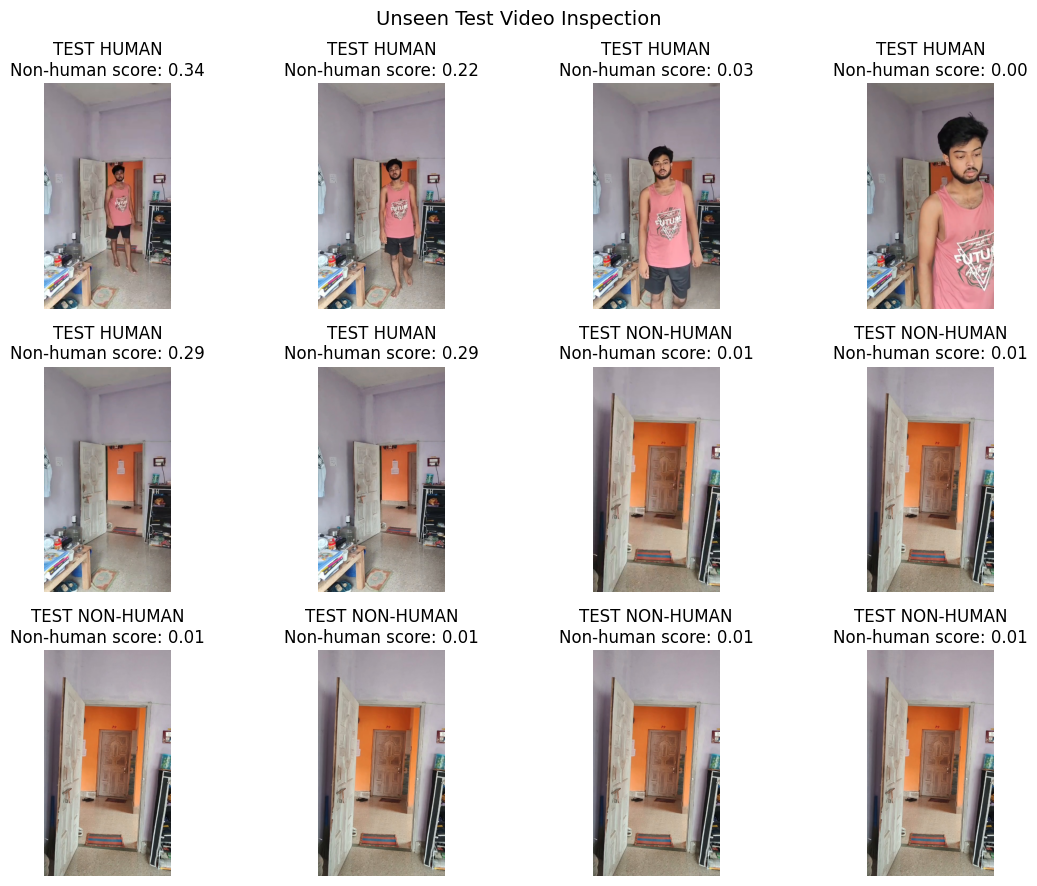

In [ ]:
# ==========================================
# STEP 9E
# INSPECT FINAL TEST VIDEO
# ==========================================

import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

test_human_dir = os.path.join(
    SPLIT_BASE,
    "test",
    "human"
)

test_nonhuman_dir = os.path.join(
    SPLIT_BASE,
    "test",
    "non_human"
)

human_files = sorted(
    glob.glob(
        os.path.join(test_human_dir, "*.jpg")
    )
)

nonhuman_files = sorted(
    glob.glob(
        os.path.join(test_nonhuman_dir, "*.jpg")
    )
)

# Take 6 samples from the test HUMAN video
human_indices = np.linspace(
    0,
    len(human_files) - 1,
    min(6, len(human_files)),
    dtype=int
)

# Take 6 samples from the test NON-HUMAN video
nonhuman_indices = np.linspace(
    0,
    len(nonhuman_files) - 1,
    min(6, len(nonhuman_files)),
    dtype=int
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9)
)

axes = axes.flatten()

# Human test samples
for i, idx in enumerate(human_indices):

    img = Image.open(
        human_files[idx]
    )

    score = model_v2.predict(
        np.expand_dims(
            np.array(img).astype(
                "float32"
            ) / 255.0,
            axis=0
        ),
        verbose=0
    )[0][0]

    axes[i].imshow(img)
    axes[i].set_title(
        f"TEST HUMAN\n"
        f"Non-human score: {score:.2f}"
    )
    axes[i].axis("off")


# Non-human test samples
for i, idx in enumerate(nonhuman_indices):

    position = 6 + i

    img = Image.open(
        nonhuman_files[idx]
    )

    score = model_v2.predict(
        np.expand_dims(
            np.array(img).astype(
                "float32"
            ) / 255.0,
            axis=0
        ),
        verbose=0
    )[0][0]

    axes[position].imshow(img)
    axes[position].set_title(
        f"TEST NON-HUMAN\n"
        f"Non-human score: {score:.2f}"
    )
    axes[position].axis("off")


plt.suptitle(
    "Unseen Test Video Inspection",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 9F
# FIND OPTIMAL DECISION THRESHOLD
# ==========================================

import numpy as np
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------
# Collect validation predictions
# ------------------------------------------

val_scores = []
val_labels = []

for images, labels in val_normalized_v2:

    scores = model_v2.predict(
        images,
        verbose=0
    ).reshape(-1)

    val_scores.extend(scores)
    val_labels.extend(
        labels.numpy().reshape(-1)
    )

val_scores = np.array(val_scores)
val_labels = np.array(
    val_labels
).astype(int)


# ------------------------------------------
# Search thresholds
# ------------------------------------------

thresholds = np.arange(
    0.01,
    1.00,
    0.01
)

best_threshold = 0
best_balanced_accuracy = 0

print("======================================")
print("THRESHOLD SEARCH")
print("======================================")

for threshold in thresholds:

    predictions = (
        val_scores >= threshold
    ).astype(int)

    score = balanced_accuracy_score(
        val_labels,
        predictions
    )

    if score > best_balanced_accuracy:

        best_balanced_accuracy = score
        best_threshold = threshold


print(
    f"Best threshold: "
    f"{best_threshold:.2f}"
)

print(
    f"Validation balanced accuracy: "
    f"{best_balanced_accuracy * 100:.2f}%"
)


# ------------------------------------------
# Detailed validation result
# ------------------------------------------

val_pred_opt = (
    val_scores >= best_threshold
).astype(int)

print()
print("Validation accuracy:",
      f"{accuracy_score(val_labels, val_pred_opt) * 100:.2f}%")

print("Validation precision:",
      f"{precision_score(val_labels, val_pred_opt, zero_division=0) * 100:.2f}%")

print("Validation recall:",
      f"{recall_score(val_labels, val_pred_opt, zero_division=0) * 100:.2f}%")

print("Validation F1:",
      f"{f1_score(val_labels, val_pred_opt, zero_division=0) * 100:.2f}%")

THRESHOLD SEARCH
Best threshold: 0.16
Validation balanced accuracy: 79.92%

Validation accuracy: 76.16%
Validation precision: 62.97%
Validation recall: 99.50%
Validation F1: 77.13%


In [ ]:
# ==========================================
# STEP 9G
# TEST USING VALIDATION-SELECTED THRESHOLD
# ==========================================

test_scores = []
test_labels = []

for images, labels in test_normalized_v2:

    scores = model_v2.predict(
        images,
        verbose=0
    ).reshape(-1)

    test_scores.extend(scores)
    test_labels.extend(
        labels.numpy().reshape(-1)
    )

test_scores = np.array(test_scores)

test_labels = np.array(
    test_labels
).astype(int)


# Apply threshold selected ONLY from validation
test_pred_opt = (
    test_scores >= best_threshold
).astype(int)


print("======================================")
print("OPTIMIZED THRESHOLD TEST")
print("======================================")

print(
    "Threshold:",
    f"{best_threshold:.2f}"
)

print(
    "Test accuracy:",
    f"{accuracy_score(test_labels, test_pred_opt) * 100:.2f}%"
)

print(
    "Test balanced accuracy:",
    f"{balanced_accuracy_score(test_labels, test_pred_opt) * 100:.2f}%"
)

print(
    "Test precision:",
    f"{precision_score(test_labels, test_pred_opt, zero_division=0) * 100:.2f}%"
)

print(
    "Test recall:",
    f"{recall_score(test_labels, test_pred_opt, zero_division=0) * 100:.2f}%"
)

print(
    "Test F1:",
    f"{f1_score(test_labels, test_pred_opt, zero_division=0) * 100:.2f}%"
)

OPTIMIZED THRESHOLD TEST
Threshold: 0.16
Test accuracy: 15.08%
Test balanced accuracy: 18.24%
Test precision: 0.00%
Test recall: 0.00%
Test F1: 0.00%


In [ ]:
from google.colab import files

print("Upload the FINAL 11 videos:")
print("7 human + 4 non-human")

new_uploaded = files.upload()

print()
print("======================================")
print("NEW VIDEOS UPLOADED")
print("======================================")
print("Files:", len(new_uploaded))

for filename in new_uploaded.keys():
    print(filename)

Upload the FINAL 11 videos:
7 human + 4 non-human


Saving huamn_14.mp4 to huamn_14.mp4
Saving human_09.mp4 to human_09.mp4
Saving human_10.mp4 to human_10.mp4
Saving human_11.mp4 to human_11.mp4
Saving human_12.mp4 to human_12.mp4
Saving human_13.mp4 to human_13.mp4
Saving human_15.mp4 to human_15.mp4
Saving nonhuman_09.mp4 to nonhuman_09.mp4
Saving nonhuman_10.mp4 to nonhuman_10.mp4
Saving nonhuman_11.mp4 to nonhuman_11.mp4
Saving nonhuman_12.mp4 to nonhuman_12.mp4

NEW VIDEOS UPLOADED
Files: 11
huamn_14.mp4
human_09.mp4
human_10.mp4
human_11.mp4
human_12.mp4
human_13.mp4
human_15.mp4
nonhuman_09.mp4
nonhuman_10.mp4
nonhuman_11.mp4
nonhuman_12.mp4


In [ ]:
# ==========================================
# STEP 10A
# ADD FINAL 11 VIDEOS + EXTRACT FRAMES
# ==========================================

import os
import cv2
import shutil
import glob

BASE = "/content/edge_ai_project"

HUMAN_VIDEOS = os.path.join(
    BASE, "human_videos"
)

NONHUMAN_VIDEOS = os.path.join(
    BASE, "nonhuman_videos"
)

HUMAN_IMAGES = os.path.join(
    BASE, "dataset", "human"
)

NONHUMAN_IMAGES = os.path.join(
    BASE, "dataset", "non_human"
)

# Make sure folders exist
for folder in [
    HUMAN_VIDEOS,
    NONHUMAN_VIDEOS,
    HUMAN_IMAGES,
    NONHUMAN_IMAGES
]:
    os.makedirs(folder, exist_ok=True)


# ==========================================
# 1. MOVE NEW VIDEOS INTO VIDEO FOLDERS
# ==========================================

new_human = 0
new_nonhuman = 0

for filename in os.listdir("/content"):

    if not filename.lower().endswith(".mp4"):
        continue

    source = os.path.join(
        "/content",
        filename
    )

    lower = filename.lower()

    if lower.startswith("human_"):

        destination = os.path.join(
            HUMAN_VIDEOS,
            filename
        )

        # Only move if not already present
        if not os.path.exists(destination):
            shutil.move(
                source,
                destination
            )
            new_human += 1

    elif lower.startswith("nonhuman_"):

        destination = os.path.join(
            NONHUMAN_VIDEOS,
            filename
        )

        if not os.path.exists(destination):
            shutil.move(
                source,
                destination
            )
            new_nonhuman += 1


print("======================================")
print("NEW VIDEOS ORGANIZED")
print("======================================")

print("New human videos:", new_human)
print("New non-human videos:", new_nonhuman)


# ==========================================
# 2. EXTRACT FRAMES
# ==========================================

def extract_new_frames(
    video_folder,
    output_folder,
    prefix,
    frame_interval=5
):

    videos = sorted(
        glob.glob(
            os.path.join(
                video_folder,
                "*.mp4"
            )
        )
    )

    total_frames = 0

    for video_path in videos:

        video_name = os.path.splitext(
            os.path.basename(video_path)
        )[0]

        # Only process videos whose frames
        # are not already present
        existing_pattern = os.path.join(
            output_folder,
            f"{prefix}_{video_name}_*.jpg"
        )

        if glob.glob(existing_pattern):
            continue

        cap = cv2.VideoCapture(
            video_path
        )

        frame_number = 0

        while True:

            ret, frame = cap.read()

            if not ret:
                break

            if frame_number % frame_interval == 0:

                filename = (
                    f"{prefix}_{video_name}_"
                    f"{frame_number:06d}.jpg"
                )

                output_path = os.path.join(
                    output_folder,
                    filename
                )

                cv2.imwrite(
                    output_path,
                    frame
                )

                total_frames += 1

            frame_number += 1

        cap.release()

    return total_frames


# Process only the newly added videos
human_new_frames = extract_new_frames(
    HUMAN_VIDEOS,
    HUMAN_IMAGES,
    "human",
    frame_interval=5
)

nonhuman_new_frames = extract_new_frames(
    NONHUMAN_VIDEOS,
    NONHUMAN_IMAGES,
    "nonhuman",
    frame_interval=5
)


# ==========================================
# 3. FINAL DATASET COUNT
# ==========================================

all_human_images = glob.glob(
    os.path.join(
        HUMAN_IMAGES,
        "*.jpg"
    )
)

all_nonhuman_images = glob.glob(
    os.path.join(
        NONHUMAN_IMAGES,
        "*.jpg"
    )
)

print()
print("======================================")
print("FINAL DATASET UPDATED")
print("======================================")

print(
    "New human frames:",
    human_new_frames
)

print(
    "New non-human frames:",
    nonhuman_new_frames
)

print()
print(
    "TOTAL human frames:",
    len(all_human_images)
)

print(
    "TOTAL non-human frames:",
    len(all_nonhuman_images)
)

print()
print("TOTAL videos:")
print(
    "Human:",
    len(glob.glob(
        os.path.join(
            HUMAN_VIDEOS,
            "*.mp4"
        )
    ))
)

print(
    "Non-human:",
    len(glob.glob(
        os.path.join(
            NONHUMAN_VIDEOS,
            "*.mp4"
        )
    ))
)

NEW VIDEOS ORGANIZED
New human videos: 6
New non-human videos: 4

FINAL DATASET UPDATED
New human frames: 454
New non-human frames: 303

TOTAL human frames: 1323
TOTAL non-human frames: 1121

TOTAL videos:
Human: 14
Non-human: 12


In [ ]:
# ==========================================
# STEP 10B
# FINAL VIDEO-LEVEL DATASET SPLIT
# ==========================================

import os
import glob
import shutil
import random

random.seed(42)

BASE = "/content/edge_ai_project"

SOURCE_HUMAN = os.path.join(
    BASE, "dataset", "human"
)

SOURCE_NONHUMAN = os.path.join(
    BASE, "dataset", "non_human"
)

SPLIT_BASE = os.path.join(
    BASE, "final_split"
)

# Remove previous final split if it exists
if os.path.exists(SPLIT_BASE):
    shutil.rmtree(SPLIT_BASE)


# ==========================================
# CREATE FOLDERS
# ==========================================

for split in ["train", "validation", "test"]:

    for cls in ["human", "non_human"]:

        os.makedirs(
            os.path.join(
                SPLIT_BASE,
                split,
                cls
            ),
            exist_ok=True
        )


# ==========================================
# FUNCTION TO GET VIDEO ID
# ==========================================

def get_video_id(filename):

    name = os.path.splitext(
        os.path.basename(filename)
    )[0]

    # Example:
    # human_human_01_000125
    # → human_01

    parts = name.split("_")

    for i in range(len(parts) - 1):

        if parts[i].isdigit():
            return "_".join(parts[i-1:i+1])

    return name


# ==========================================
# GROUP FRAMES BY ORIGINAL VIDEO
# ==========================================

def group_by_video(source_folder):

    files = sorted(
        glob.glob(
            os.path.join(
                source_folder,
                "*.jpg"
            )
        )
    )

    groups = {}

    for filepath in files:

        filename = os.path.basename(
            filepath
        )

        video_id = get_video_id(
            filename
        )

        if video_id not in groups:
            groups[video_id] = []

        groups[video_id].append(
            filepath
        )

    return groups


human_groups = group_by_video(
    SOURCE_HUMAN
)

nonhuman_groups = group_by_video(
    SOURCE_NONHUMAN
)


print("======================================")
print("FINAL VIDEO GROUPS")
print("======================================")

print(
    "Human videos:",
    len(human_groups)
)

print(
    "Non-human videos:",
    len(nonhuman_groups)
)


# ==========================================
# SPLIT FUNCTION
# ==========================================

def split_videos(
    groups,
    train_count,
    validation_count
):

    video_ids = list(
        groups.keys()
    )

    random.shuffle(
        video_ids
    )

    train_ids = video_ids[
        :train_count
    ]

    validation_ids = video_ids[
        train_count:
        train_count + validation_count
    ]

    test_ids = video_ids[
        train_count + validation_count:
    ]

    return (
        train_ids,
        validation_ids,
        test_ids
    )


human_train, human_val, human_test = split_videos(
    human_groups,
    10,
    2
)

nonhuman_train, nonhuman_val, nonhuman_test = split_videos(
    nonhuman_groups,
    8,
    2
)


# ==========================================
# COPY FRAMES
# ==========================================

def copy_groups(
    groups,
    video_ids,
    destination
):

    count = 0

    for video_id in video_ids:

        for filepath in groups[video_id]:

            shutil.copy2(
                filepath,
                destination
            )

            count += 1

    return count


train_human_count = copy_groups(
    human_groups,
    human_train,
    os.path.join(
        SPLIT_BASE,
        "train",
        "human"
    )
)

val_human_count = copy_groups(
    human_groups,
    human_val,
    os.path.join(
        SPLIT_BASE,
        "validation",
        "human"
    )
)

test_human_count = copy_groups(
    human_groups,
    human_test,
    os.path.join(
        SPLIT_BASE,
        "test",
        "human"
    )
)


train_nonhuman_count = copy_groups(
    nonhuman_groups,
    nonhuman_train,
    os.path.join(
        SPLIT_BASE,
        "train",
        "non_human"
    )
)

val_nonhuman_count = copy_groups(
    nonhuman_groups,
    nonhuman_val,
    os.path.join(
        SPLIT_BASE,
        "validation",
        "non_human"
    )
)

test_nonhuman_count = copy_groups(
    nonhuman_groups,
    nonhuman_test,
    os.path.join(
        SPLIT_BASE,
        "test",
        "non_human"
    )
)


# ==========================================
# FINAL REPORT
# ==========================================

print()
print("======================================")
print("FINAL DATASET SPLIT COMPLETE")
print("======================================")

print()
print("HUMAN")
print("Training videos:", human_train)
print("Validation videos:", human_val)
print("Test videos:", human_test)

print()
print("NON-HUMAN")
print("Training videos:", nonhuman_train)
print("Validation videos:", nonhuman_val)
print("Test videos:", nonhuman_test)

print()
print("IMAGE COUNTS")
print("--------------------------------------")

print(
    "Human:"
)

print(
    "  Train:",
    train_human_count
)

print(
    "  Validation:",
    val_human_count
)

print(
    "  Test:",
    test_human_count
)

print()
print(
    "Non-human:"
)

print(
    "  Train:",
    train_nonhuman_count
)

print(
    "  Validation:",
    val_nonhuman_count
)

print(
    "  Test:",
    test_nonhuman_count
)

FINAL VIDEO GROUPS
Human videos: 14
Non-human videos: 12

FINAL DATASET SPLIT COMPLETE

HUMAN
Training videos: ['human_09', 'human_13', 'human_08', 'human_07', 'human_15', 'human_12', 'human_06', 'human_03', 'human_10', 'human_04']
Validation videos: ['human_05', 'human_01']
Test videos: ['human_02', 'human_11']

NON-HUMAN
Training videos: ['nonhuman_06', 'nonhuman_08', 'nonhuman_03', 'nonhuman_10', 'nonhuman_11', 'nonhuman_07', 'nonhuman_05', 'nonhuman_09']
Validation videos: ['nonhuman_04', 'nonhuman_02']
Test videos: ['nonhuman_12', 'nonhuman_01']

IMAGE COUNTS
--------------------------------------
Human:
  Train: 1010
  Validation: 194
  Test: 119

Non-human:
  Train: 726
  Validation: 213
  Test: 182


In [ ]:
# ==========================================
# STEP 10C
# FINAL CNN DATASET PREPARATION
# ==========================================

import tensorflow as tf
import numpy as np
import os

# ------------------------------------------
# SETTINGS
# ------------------------------------------

IMG_SIZE = (96, 96)
BATCH_SIZE = 32
SEED = 42

TRAIN_DIR = os.path.join(
    SPLIT_BASE,
    "train"
)

VAL_DIR = os.path.join(
    SPLIT_BASE,
    "validation"
)

TEST_DIR = os.path.join(
    SPLIT_BASE,
    "test"
)

# ------------------------------------------
# LOAD DATASETS
# ------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

# ------------------------------------------
# CLASS INFORMATION
# ------------------------------------------

print("======================================")
print("FINAL CNN DATASET")
print("======================================")

print()
print("Class names:")
print(train_ds.class_names)

print()
print("Training batches:",
      tf.data.experimental.cardinality(
          train_ds
      ).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(
          val_ds
      ).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(
          test_ds
      ).numpy())

# ------------------------------------------
# NORMALIZATION
# ------------------------------------------

normalization = tf.keras.layers.Rescaling(
    1.0 / 255.0
)

train_normalized = train_ds.map(
    lambda x, y: (
        normalization(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_normalized = val_ds.map(
    lambda x, y: (
        normalization(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_normalized = test_ds.map(
    lambda x, y: (
        normalization(x),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

# ------------------------------------------
# PERFORMANCE
# ------------------------------------------

train_normalized = train_normalized.prefetch(
    tf.data.AUTOTUNE
)

val_normalized = val_normalized.prefetch(
    tf.data.AUTOTUNE
)

test_normalized = test_normalized.prefetch(
    tf.data.AUTOTUNE
)

# ------------------------------------------
# CLASS COUNTS
# ------------------------------------------

human_count = 1010
nonhuman_count = 726

total_count = (
    human_count +
    nonhuman_count
)

# Balanced class weights
class_weight = {
    0: total_count / (
        2 * human_count
    ),
    1: total_count / (
        2 * nonhuman_count
    )
}

print()
print("Class weights:")
print(class_weight)

print()
print("======================================")
print("DATASET PREPARATION COMPLETE")
print("======================================")

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Training images:", 1736)
print("Validation images:", 407)
print("Test images:", 301)

Found 1736 files belonging to 2 classes.
Found 407 files belonging to 2 classes.
Found 301 files belonging to 2 classes.
FINAL CNN DATASET

Class names:
['human', 'non_human']

Training batches: 55
Validation batches: 13
Test batches: 10

Class weights:
{0: 0.8594059405940594, 1: 1.1955922865013775}

DATASET PREPARATION COMPLETE
Image size: (96, 96)
Batch size: 32
Training images: 1736
Validation images: 407
Test images: 301


In [ ]:
# ============================================================
# STEP 10D
# FINAL ESP32-S3 COMPATIBLE CNN
# TRAIN + EVALUATE + INT8 TFLITE + ARDUINO HEADER
# ============================================================

import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("================================================")
print("FINAL ESP32-S3 EDGE AI MODEL")
print("================================================")

# ------------------------------------------------------------
# 1. MODEL
# ------------------------------------------------------------

IMG_H = 96
IMG_W = 96

model_final = tf.keras.Sequential([

    tf.keras.Input(
        shape=(96, 96, 3),
        name="image"
    ),

    # Block 1
    tf.keras.layers.Conv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv1"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2),
        name="pool1"
    ),

    # Block 2
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv2"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2),
        name="pool2"
    ),

    # Block 3
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu",
        name="conv3"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2),
        name="pool3"
    ),

    # Compact feature representation
    tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pool"
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu",
        name="dense"
    ),

    # Output:
    # 0 = HUMAN
    # 1 = NON-HUMAN
    tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="output"
    )
])


# ------------------------------------------------------------
# 2. COMPILE
# ------------------------------------------------------------

model_final.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

print()
print("MODEL ARCHITECTURE")
print("------------------")

model_final.summary()


# ------------------------------------------------------------
# 3. TRAIN
# ------------------------------------------------------------

print()
print("================================================")
print("FINAL TRAINING")
print("================================================")

history_final = model_final.fit(
    train_normalized,
    validation_data=val_normalized,
    epochs=15,
    class_weight=class_weight,
    verbose=1
)


# ------------------------------------------------------------
# 4. VALIDATION
# ------------------------------------------------------------

print()
print("================================================")
print("FINAL VALIDATION")
print("================================================")

val_loss, val_accuracy = model_final.evaluate(
    val_normalized,
    verbose=0
)

print(
    f"Validation loss: {val_loss:.4f}"
)

print(
    f"Validation accuracy: "
    f"{val_accuracy * 100:.2f}%"
)


# ------------------------------------------------------------
# 5. FINAL UNSEEN TEST
# ------------------------------------------------------------

print()
print("================================================")
print("FINAL UNSEEN TEST")
print("================================================")

test_loss, test_accuracy = model_final.evaluate(
    test_normalized,
    verbose=0
)

print(
    f"Test loss: {test_loss:.4f}"
)

print(
    f"Test accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

y_true = []
y_pred = []

for images, labels in test_normalized:

    probabilities = model_final.predict(
        images,
        verbose=0
    ).reshape(-1)

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    y_true.extend(
        labels.numpy().reshape(-1).astype(int)
    )

    y_pred.extend(
        predictions
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)


print()
print("================================================")
print("TEST CLASSIFICATION REPORT")
print("================================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "HUMAN",
            "NON-HUMAN"
        ],
        digits=4
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred
    )
)


# ------------------------------------------------------------
# 7. SAVE KERAS MODEL
# ------------------------------------------------------------

KERAS_PATH = os.path.join(
    BASE,
    "final_human_nonhuman_cnn.keras"
)

model_final.save(
    KERAS_PATH
)

print()
print("TensorFlow/Keras model saved:")
print(KERAS_PATH)


# ------------------------------------------------------------
# 8. TFLITE CONVERSION
# ------------------------------------------------------------

print()
print("================================================")
print("CONVERTING TO TENSORFLOW LITE")
print("================================================")

converter = tf.lite.TFLiteConverter.from_keras_model(
    model_final
)

# Full integer quantization
converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]


# ------------------------------------------------------------
# REPRESENTATIVE DATASET
# ------------------------------------------------------------

def representative_dataset():

    # Use individual images, not batches
    dataset = train_normalized.unbatch()

    for image, label in dataset.take(150):

        image = tf.cast(
            image,
            tf.float32
        )

        image = tf.expand_dims(
            image,
            axis=0
        )

        yield [image]


converter.representative_dataset = (
    representative_dataset
)

# Force all operations to INT8
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# Force INT8 input/output
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8


# Convert
tflite_model = converter.convert()


# ------------------------------------------------------------
# 9. SAVE TFLITE
# ------------------------------------------------------------

TFLITE_PATH = os.path.join(
    BASE,
    "final_human_nonhuman_int8.tflite"
)

with open(
    TFLITE_PATH,
    "wb"
) as f:

    f.write(
        tflite_model
    )


print()
print("TFLITE CONVERSION SUCCESSFUL")
print(
    "TFLite model:",
    TFLITE_PATH
)

print(
    "Model size:",
    len(tflite_model) / 1024,
    "KB"
)


# ------------------------------------------------------------
# 10. VERIFY TFLITE MODEL
# ------------------------------------------------------------

print()
print("================================================")
print("TFLITE MODEL VERIFICATION")
print("================================================")

interpreter = tf.lite.Interpreter(
    model_path=TFLITE_PATH
)

interpreter.allocate_tensors()

input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)

print(
    "Input shape:",
    input_details[0]["shape"]
)

print(
    "Input type:",
    input_details[0]["dtype"]
)

print(
    "Output shape:",
    output_details[0]["shape"]
)

print(
    "Output type:",
    output_details[0]["dtype"]
)

print()
print("Supported TFLite operators:")

ops = interpreter._get_ops_details()

for op in ops:
    print(
        op["op_name"]
    )


# ------------------------------------------------------------
# 11. GENERATE ARDUINO C HEADER
# ------------------------------------------------------------

HEADER_PATH = os.path.join(
    BASE,
    "edge_ai_human_nonhuman_int8_model_data.h"
)

with open(
    HEADER_PATH,
    "w"
) as f:

    f.write(
        "#ifndef EDGE_AI_HUMAN_NONHUMAN_INT8_MODEL_DATA_H\n"
    )

    f.write(
        "#define EDGE_AI_HUMAN_NONHUMAN_INT8_MODEL_DATA_H\n\n"
    )

    f.write(
        "#include <stdint.h>\n\n"
    )

    f.write(
        "const unsigned char "
        "g_human_nonhuman_int8_model[] = {\n"
    )

    for i in range(
        0,
        len(tflite_model),
        12
    ):

        chunk = tflite_model[
            i:i+12
        ]

        f.write(
            "  "
            + ", ".join(
                f"0x{byte:02x}"
                for byte in chunk
            )
            + ",\n"
        )

    f.write(
        "};\n\n"
    )

    f.write(
        "const unsigned int "
        "g_human_nonhuman_int8_model_len = "
        f"{len(tflite_model)};\n\n"
    )

    f.write(
        "#endif\n"
    )


print()
print("================================================")
print("ARDUINO HEADER CREATED")
print("================================================")

print(
    HEADER_PATH
)

print()
print("================================================")
print("FINAL MODEL BUILD COMPLETE")
print("================================================")

print("1. TensorFlow/Keras model  : READY")
print("2. TFLite model            : READY")
print("3. Full INT8 quantization  : READY")
print("4. INT8 input/output       : READY")
print("5. Arduino C header        : READY")

FINAL ESP32-S3 EDGE AI MODEL

MODEL ARCHITECTURE
------------------


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)


FINAL TRAINING
Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 526ms/step - accuracy: 0.5484 - loss: 0.6928 - val_accuracy: 0.3710 - val_loss: 0.6946
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 423ms/step - accuracy: 0.5783 - loss: 0.6747 - val_accuracy: 0.3710 - val_loss: 0.7219
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 490ms/step - accuracy: 0.7074 - loss: 0.5813 - val_accuracy: 0.3710 - val_loss: 0.8919
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 25s 447ms/step - accuracy: 0.7748 - loss: 0.4688 - val_accuracy: 0.5504 - val_loss: 1.1058
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 452ms/step - accuracy: 0.8105 - loss: 0.3841 - val_accuracy: 0.7420 - val_loss: 1.1727
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 383ms/step - accuracy: 0.8658 - loss: 0.2942 - val_accuracy: 0.7420 - val_loss: 1.1734
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 424ms/step - accuracy: 0.9228 - loss: 0.2128 - val_accuracy: 0.5553 - val_loss: 0.5339
Epoch 8/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 425ms/step - accuracy: 0.9724 - loss: 0

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



TFLITE CONVERSION SUCCESSFUL
TFLite model: /content/edge_ai_project/final_human_nonhuman_int8.tflite
Model size: 33.28125 KB

TFLITE MODEL VERIFICATION
Input shape: [ 1 96 96  3]
Input type: <class 'numpy.int8'>
Output shape: [1 1]
Output type: <class 'numpy.int8'>

Supported TFLite operators:
CONV_2D
MAX_POOL_2D
CONV_2D
MAX_POOL_2D
CONV_2D
MAX_POOL_2D
MEAN
FULLY_CONNECTED
FULLY_CONNECTED
LOGISTIC
DELEGATE

ARDUINO HEADER CREATED
/content/edge_ai_project/edge_ai_human_nonhuman_int8_model_data.h

FINAL MODEL BUILD COMPLETE
1. TensorFlow/Keras model  : READY
2. TFLite model            : READY
3. Full INT8 quantization  : READY
4. INT8 input/output       : READY
5. Arduino C header        : READY


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ==========================================
# DOWNLOAD FINAL ESP32-S3 MODEL FILES
# ==========================================

from google.colab import files
import os

BASE = "/content/edge_ai_project"

files_to_download = [
    os.path.join(
        BASE,
        "final_human_nonhuman_int8.tflite"
    ),
    os.path.join(
        BASE,
        "edge_ai_human_nonhuman_int8_model_data.h"
    ),
    os.path.join(
        BASE,
        "final_human_nonhuman_cnn.keras"
    )
]

print("======================================")
print("FINAL MODEL FILES")
print("======================================")

for path in files_to_download:

    if os.path.exists(path):

        size_kb = os.path.getsize(path) / 1024

        print(
            os.path.basename(path),
            f"({size_kb:.2f} KB)"
        )

        files.download(path)

    else:

        print(
            "NOT FOUND:",
            path
        )

FINAL MODEL FILES
final_human_nonhuman_int8.tflite (33.28 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

edge_ai_human_nonhuman_int8_model_data.h (205.47 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

final_human_nonhuman_cnn.keras (345.40 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STEP 11A
# ACTIVITY CLASSIFICATION PROJECT SETUP
# ============================================================

import os
import shutil
import numpy as np
import tensorflow as tf

print("====================================================")
print("ACTIVITY CLASSIFICATION - PROJECT SETUP")
print("====================================================")

ACTIVITY_BASE = "/content/activity_ai_project"

ACTIVITY_VIDEO_DIR = os.path.join(ACTIVITY_BASE, "videos")
ACTIVITY_FRAME_DIR = os.path.join(ACTIVITY_BASE, "frames")

CLASSES = [
    "standing",
    "walking",
    "sitting",
    "falling"
]

# Create directories
for cls in CLASSES:
    os.makedirs(os.path.join(ACTIVITY_VIDEO_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(ACTIVITY_FRAME_DIR, cls), exist_ok=True)

print("\nActivity project directory:")
print(ACTIVITY_BASE)

print("\nClasses:")
for i, cls in enumerate(CLASSES):
    print(i, "->", cls.upper())

print("\nDirectory setup completed.")

ACTIVITY CLASSIFICATION - PROJECT SETUP

Activity project directory:
/content/activity_ai_project

Classes:
0 -> STANDING
1 -> WALKING
2 -> SITTING
3 -> FALLING

Directory setup completed.


In [ ]:
# ============================================================
# STEP 11B
# UPLOAD ACTIVITY VIDEOS
# ============================================================

from google.colab import files
import os
import shutil

print("====================================================")
print("UPLOAD ACTIVITY VIDEOS")
print("====================================================")

print("""
Rename your videos before uploading using:

standing_01.mp4
walking_01.mp4
sitting_01.mp4
falling_01.mp4

The filename prefix determines the class.
""")

uploaded = files.upload()

for filename in uploaded.keys():

    lower_name = filename.lower()

    if lower_name.startswith("standing"):
        target_class = "standing"

    elif lower_name.startswith("walking"):
        target_class = "walking"

    elif lower_name.startswith("sitting"):
        target_class = "sitting"

    elif lower_name.startswith("falling"):
        target_class = "falling"

    else:
        print("SKIPPED - unknown class:", filename)
        continue

    source = filename
    destination = os.path.join(
        ACTIVITY_VIDEO_DIR,
        target_class,
        filename
    )

    shutil.move(source, destination)

    print(
        "Added:",
        filename,
        "->",
        target_class.upper()
    )

print("\nUpload completed.")

UPLOAD ACTIVITY VIDEOS

Rename your videos before uploading using:

standing_01.mp4
walking_01.mp4
sitting_01.mp4
falling_01.mp4

The filename prefix determines the class.



Saving falling_01.mp4 to falling_01.mp4
Saving falling_02.mp4 to falling_02.mp4
Saving falling_03.mp4 to falling_03.mp4
Saving falling_04.mp4 to falling_04.mp4
Saving falling_05.mp4 to falling_05.mp4
Saving sitting_01.mp4 to sitting_01.mp4
Saving sitting_02.mp4 to sitting_02.mp4
Saving sitting_03.mp4 to sitting_03.mp4
Saving sitting_04.mp4 to sitting_04.mp4
Saving sitting_05.mp4 to sitting_05.mp4
Saving standing_01.mp4 to standing_01.mp4
Saving standing_02.mp4 to standing_02.mp4
Saving standing_03.mp4 to standing_03.mp4
Saving standing_04.mp4 to standing_04.mp4
Saving standing_05.mp4 to standing_05.mp4
Saving walking_01.mp4 to walking_01.mp4
Saving walking_02.mp4 to walking_02.mp4
Saving walking_03.mp4 to walking_03.mp4
Saving walking_04.mp4 to walking_04.mp4
Saving walking_05.mp4 to walking_05.mp4
Added: falling_01.mp4 -> FALLING
Added: falling_02.mp4 -> FALLING
Added: falling_03.mp4 -> FALLING
Added: falling_04.mp4 -> FALLING
Added: falling_05.mp4 -> FALLING
Added: sitting_01.mp4 -> 

In [ ]:
# ============================================================
# STEP 11C
# VIDEO-LEVEL SPLIT + FRAME EXTRACTION
# ESP32-S3 ACTIVITY CLASSIFICATION
# ============================================================

import os
import cv2
import random
import shutil

print("====================================================")
print("STEP 11C - ACTIVITY DATASET PREPARATION")
print("====================================================")

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

IMG_SIZE = 96
FRAMES_PER_VIDEO = 20

SEED = 42
random.seed(SEED)

# Dataset directories
SPLIT_BASE = os.path.join(ACTIVITY_BASE, "dataset")

TRAIN_VIDEO_DIR = os.path.join(SPLIT_BASE, "train_videos")
VAL_VIDEO_DIR   = os.path.join(SPLIT_BASE, "val_videos")
TEST_VIDEO_DIR  = os.path.join(SPLIT_BASE, "test_videos")

TRAIN_FRAME_DIR = os.path.join(SPLIT_BASE, "train")
VAL_FRAME_DIR   = os.path.join(SPLIT_BASE, "validation")
TEST_FRAME_DIR  = os.path.join(SPLIT_BASE, "test")

# ------------------------------------------------------------
# CREATE DIRECTORIES
# ------------------------------------------------------------

for base_dir in [
    TRAIN_VIDEO_DIR,
    VAL_VIDEO_DIR,
    TEST_VIDEO_DIR,
    TRAIN_FRAME_DIR,
    VAL_FRAME_DIR,
    TEST_FRAME_DIR
]:
    os.makedirs(base_dir, exist_ok=True)

    for cls in CLASSES:
        os.makedirs(
            os.path.join(base_dir, cls),
            exist_ok=True
        )

# ------------------------------------------------------------
# FUNCTION: SPLIT VIDEOS
# ------------------------------------------------------------

def split_videos():

    print("\nVIDEO SPLIT")
    print("------------")

    for cls in CLASSES:

        source_dir = os.path.join(
            ACTIVITY_VIDEO_DIR,
            cls
        )

        videos = [
            f for f in os.listdir(source_dir)
            if f.lower().endswith(
                (".mp4", ".avi", ".mov", ".mkv")
            )
        ]

        videos.sort()
        random.shuffle(videos)

        total = len(videos)

        if total < 5:
            raise ValueError(
                f"{cls}: Need at least 5 videos, found {total}"
            )

        # 60% train / 20% validation / 20% test
        train_count = int(total * 0.6)
        val_count = int(total * 0.2)

        # Ensure at least one video for validation/test
        train_count = max(train_count, 3)
        val_count = max(val_count, 1)

        train_videos = videos[:train_count]
        val_videos = videos[
            train_count:train_count + val_count
        ]
        test_videos = videos[
            train_count + val_count:
        ]

        print(f"\n{cls.upper()}")
        print("Total :", len(videos))
        print("Train :", len(train_videos))
        print("Val   :", len(val_videos))
        print("Test  :", len(test_videos))

        # Copy videos
        for filename in train_videos:
            shutil.copy2(
                os.path.join(source_dir, filename),
                os.path.join(
                    TRAIN_VIDEO_DIR,
                    cls,
                    filename
                )
            )

        for filename in val_videos:
            shutil.copy2(
                os.path.join(source_dir, filename),
                os.path.join(
                    VAL_VIDEO_DIR,
                    cls,
                    filename
                )
            )

        for filename in test_videos:
            shutil.copy2(
                os.path.join(source_dir, filename),
                os.path.join(
                    TEST_VIDEO_DIR,
                    cls,
                    filename
                )
            )

# ------------------------------------------------------------
# FUNCTION: EXTRACT FRAMES
# ------------------------------------------------------------

def extract_frames(video_base_dir, frame_base_dir, split_name):

    print("\n====================================================")
    print(f"EXTRACTING {split_name.upper()} FRAMES")
    print("====================================================")

    total_frames = 0

    for cls in CLASSES:

        video_dir = os.path.join(
            video_base_dir,
            cls
        )

        output_dir = os.path.join(
            frame_base_dir,
            cls
        )

        videos = [
            f for f in os.listdir(video_dir)
            if f.lower().endswith(
                (".mp4", ".avi", ".mov", ".mkv")
            )
        ]

        videos.sort()

        class_frames = 0

        for video_index, filename in enumerate(videos):

            video_path = os.path.join(
                video_dir,
                filename
            )

            cap = cv2.VideoCapture(video_path)

            if not cap.isOpened():
                print("WARNING: Could not open:", filename)
                continue

            total_video_frames = int(
                cap.get(cv2.CAP_PROP_FRAME_COUNT)
            )

            if total_video_frames <= 0:
                cap.release()
                continue

            # Select evenly spaced frames
            frame_indices = [
                int(x)
                for x in __import__("numpy").linspace(
                    0,
                    total_video_frames - 1,
                    min(
                        FRAMES_PER_VIDEO,
                        total_video_frames
                    )
                )
            ]

            for frame_number, frame_index in enumerate(
                frame_indices
            ):

                cap.set(
                    cv2.CAP_PROP_POS_FRAMES,
                    frame_index
                )

                success, frame = cap.read()

                if not success:
                    continue

                # Resize to ESP32 model input size
                frame = cv2.resize(
                    frame,
                    (IMG_SIZE, IMG_SIZE),
                    interpolation=cv2.INTER_AREA
                )

                output_filename = (
                    f"{split_name}_"
                    f"{cls}_"
                    f"v{video_index+1:02d}_"
                    f"f{frame_number+1:02d}.jpg"
                )

                output_path = os.path.join(
                    output_dir,
                    output_filename
                )

                cv2.imwrite(
                    output_path,
                    frame,
                    [
                        cv2.IMWRITE_JPEG_QUALITY,
                        90
                    ]
                )

                class_frames += 1
                total_frames += 1

            cap.release()

        print(
            f"{cls.upper():10s} -> "
            f"{class_frames} frames"
        )

    print(
        f"\nTotal {split_name} frames:",
        total_frames
    )

    return total_frames


# ------------------------------------------------------------
# RUN VIDEO SPLIT
# ------------------------------------------------------------

split_videos()

# ------------------------------------------------------------
# EXTRACT FRAMES
# ------------------------------------------------------------

train_count = extract_frames(
    TRAIN_VIDEO_DIR,
    TRAIN_FRAME_DIR,
    "train"
)

val_count = extract_frames(
    VAL_VIDEO_DIR,
    VAL_FRAME_DIR,
    "val"
)

test_count = extract_frames(
    TEST_VIDEO_DIR,
    TEST_FRAME_DIR,
    "test"
)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n====================================================")
print("ACTIVITY DATASET READY")
print("====================================================")

print("Training frames   :", train_count)
print("Validation frames :", val_count)
print("Test frames       :", test_count)

print("\nClasses:")

for i, cls in enumerate(CLASSES):
    print(f"{i}: {cls.upper()}")

print("\nImage size:", IMG_SIZE, "x", IMG_SIZE)
print("Frames/video:", FRAMES_PER_VIDEO)

print("\nSTEP 11C COMPLETED.")

STEP 11C - ACTIVITY DATASET PREPARATION

VIDEO SPLIT
------------

STANDING
Total : 5
Train : 3
Val   : 1
Test  : 1

WALKING
Total : 5
Train : 3
Val   : 1
Test  : 1

SITTING
Total : 5
Train : 3
Val   : 1
Test  : 1

FALLING
Total : 5
Train : 3
Val   : 1
Test  : 1

EXTRACTING TRAIN FRAMES
STANDING   -> 60 frames
WALKING    -> 60 frames
SITTING    -> 60 frames
FALLING    -> 60 frames

Total train frames: 240

EXTRACTING VAL FRAMES
STANDING   -> 20 frames
WALKING    -> 20 frames
SITTING    -> 20 frames
FALLING    -> 20 frames

Total val frames: 80

EXTRACTING TEST FRAMES
STANDING   -> 20 frames
WALKING    -> 20 frames
SITTING    -> 20 frames
FALLING    -> 20 frames

Total test frames: 80

ACTIVITY DATASET READY
Training frames   : 240
Validation frames : 80
Test frames       : 80

Classes:
0: STANDING
1: WALKING
2: SITTING
3: FALLING

Image size: 96 x 96
Frames/video: 20

STEP 11C COMPLETED.


In [ ]:
# ============================================================
# STEP 11D
# ESP32-S3 COMPATIBLE ACTIVITY CNN
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models

print("====================================================")
print("STEP 11D - ACTIVITY CNN")
print("====================================================")

IMG_H = 96
IMG_W = 96
NUM_CLASSES = len(CLASSES)

activity_model = tf.keras.Sequential([

    # Input
    layers.Input(shape=(IMG_H, IMG_W, 3)),

    # Block 1
    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Feature compression
    layers.GlobalAveragePooling2D(),

    # Small classifier
    layers.Dense(32, activation="relu"),

    # 4 activity classes
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

activity_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nMODEL ARCHITECTURE")
print("====================================================")

activity_model.summary()

print("\nNumber of parameters:",
      activity_model.count_params())

print("\nClasses:")
for i, cls in enumerate(CLASSES):
    print(f"{i} -> {cls.upper()}")

print("\nSTEP 11D COMPLETED.")

STEP 11D - ACTIVITY CNN

MODEL ARCHITECTURE


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,796 (100.77 KB)

 Trainable params: 25,796 (100.77 KB)

 Non-trainable params: 0 (0.00 B)


Number of parameters: 25796

Classes:
0 -> STANDING
1 -> WALKING
2 -> SITTING
3 -> FALLING

STEP 11D COMPLETED.


In [ ]:
# ============================================================
# STEP 11E
# LOAD ACTIVITY DATASET
# ============================================================

print("====================================================")
print("STEP 11E - LOADING DATASET")
print("====================================================")

BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_FRAME_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASSES,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_FRAME_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASSES,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_FRAME_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASSES,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataset loaded successfully.")

print("Training batches   :", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches       :", tf.data.experimental.cardinality(test_ds).numpy())

print("\nClass order:")
for i, cls in enumerate(CLASSES):
    print(i, "=", cls.upper())

print("\nSTEP 11E COMPLETED.")

STEP 11E - LOADING DATASET
Found 240 files belonging to 4 classes.
Found 80 files belonging to 4 classes.
Found 80 files belonging to 4 classes.

Dataset loaded successfully.
Training batches   : 8
Validation batches : 3
Test batches       : 3

Class order:
0 = STANDING
1 = WALKING
2 = SITTING
3 = FALLING

STEP 11E COMPLETED.


In [ ]:
# ============================================================
# STEP 11F
# TRAIN ESP32-S3 ACTIVITY CLASSIFICATION MODEL
# ============================================================

import os
import tensorflow as tf
import matplotlib.pyplot as plt

print("====================================================")
print("STEP 11F - TRAINING ACTIVITY MODEL")
print("====================================================")

# ------------------------------------------------------------
# DATA AUGMENTATION
# Applied ONLY during training.
# These layers are NOT part of the final deployment model.
# ------------------------------------------------------------

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),
    tf.keras.layers.RandomBrightness(
        0.15
    ),
    tf.keras.layers.RandomContrast(
        0.15
    )
])

# ------------------------------------------------------------
# AUGMENT TRAINING DATA
# ------------------------------------------------------------

def augment_images(images, labels):
    images = tf.cast(images, tf.float32)
    images = data_augmentation(
        images,
        training=True
    )
    return images, labels


train_augmented = train_ds.map(
    augment_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Keep validation/test unchanged
train_augmented = train_augmented.prefetch(
    tf.data.AUTOTUNE
)

val_ds_ready = val_ds.prefetch(
    tf.data.AUTOTUNE
)

test_ds_ready = test_ds.prefetch(
    tf.data.AUTOTUNE
)

# ------------------------------------------------------------
# CALLBACKS
# ------------------------------------------------------------

MODEL_DIR = os.path.join(
    ACTIVITY_BASE,
    "models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_activity_cnn.keras"
)

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

EPOCHS = 30

print("\nStarting training...")
print("Maximum epochs:", EPOCHS)
print("Early stopping enabled.")
print()

history = activity_model.fit(
    train_augmented,
    validation_data=val_ds_ready,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("\n====================================================")
print("TRAINING COMPLETED")
print("====================================================")

print(
    "Best model saved at:"
)
print(BEST_MODEL_PATH)

# ------------------------------------------------------------
# BEST VALIDATION RESULT
# ------------------------------------------------------------

best_val_accuracy = max(
    history.history["val_accuracy"]
)

best_val_loss = min(
    history.history["val_loss"]
)

print(
    f"\nBest validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

STEP 11F - TRAINING ACTIVITY MODEL

Starting training...
Maximum epochs: 30
Early stopping enabled.

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.2465 - loss: 27.1052
Epoch 1: val_accuracy improved from None to 0.25000, saving model to /content/activity_ai_project/models/best_activity_cnn.keras

Epoch 1: finished saving model to /content/activity_ai_project/models/best_activity_cnn.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.2833 - loss: 17.4092 - val_accuracy: 0.2500 - val_loss: 3.9047 - learning_rate: 0.0010
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.2601 - loss: 2.9852
Epoch 2: val_accuracy improved from 0.25000 to 0.26250, saving model to /content/activity_ai_project/models/best_activity_cnn.keras

Epoch 2: finished saving model to /content/activity_ai_project/models/best_activity_cnn.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 0.2125 - loss: 2.5896 - val_accuracy: 0.2625 - val_loss: 2.6141 - learning_rate: 0.0010


In [ ]:
# ============================================================
# STEP 11G - FIND ACTIVITY DATASET
# ============================================================

import os

print("====================================================")
print("SEARCHING FOR ACTIVITY DATASET")
print("====================================================")

BASE = "/content/activity_ai_project"

print("\nBase directory exists:", os.path.exists(BASE))

if os.path.exists(BASE):

    print("\nContents of activity_ai_project:")

    for item in os.listdir(BASE):
        path = os.path.join(BASE, item)

        if os.path.isdir(path):
            print("  [DIR] ", item)
        else:
            print("  [FILE]", item)

print("\n----------------------------------------------------")
print("SEARCHING FOR TEST FRAMES")
print("----------------------------------------------------")

found = []

for root, dirs, files in os.walk("/content"):

    image_files = [
        f for f in files
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    if image_files:
        # Only show directories related to activity/test
        root_lower = root.lower()

        if (
            "activity" in root_lower
            or "test" in root_lower
        ):
            found.append(
                (root, len(image_files))
            )

for root, count in found:

    print(
        f"{count:4d} images -> {root}"
    )

print("\n====================================================")
print("SEARCH COMPLETED")
print("====================================================")

SEARCHING FOR ACTIVITY DATASET

Base directory exists: False

----------------------------------------------------
SEARCHING FOR TEST FRAMES
----------------------------------------------------

SEARCH COMPLETED


In [ ]:
# ============================================================
# ACTIVITY PROJECT - PERSISTENT GOOGLE DRIVE STORAGE
# ============================================================

from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security"

ACTIVITY_BASE = os.path.join(
    DRIVE_BASE,
    "activity_ai_project"
)

os.makedirs(
    ACTIVITY_BASE,
    exist_ok=True
)

print("====================================================")
print("GOOGLE DRIVE STORAGE READY")
print("====================================================")

print("Activity project:")
print(ACTIVITY_BASE)

Mounted at /content/drive
GOOGLE DRIVE STORAGE READY
Activity project:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project


In [ ]:
# ============================================================
# RECREATE ACTIVITY PROJECT DIRECTORIES
# ============================================================

import os

CLASSES = [
    "standing",
    "walking",
    "sitting",
    "falling"
]

ACTIVITY_VIDEO_DIR = os.path.join(
    ACTIVITY_BASE,
    "videos"
)

for cls in CLASSES:
    os.makedirs(
        os.path.join(
            ACTIVITY_VIDEO_DIR,
            cls
        ),
        exist_ok=True
    )

print("====================================================")
print("ACTIVITY DIRECTORIES CREATED")
print("====================================================")

for cls in CLASSES:
    print(
        cls.upper(),
        "->",
        os.path.join(
            ACTIVITY_VIDEO_DIR,
            cls
        )
    )

ACTIVITY DIRECTORIES CREATED
STANDING -> /content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/videos/standing
WALKING -> /content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/videos/walking
SITTING -> /content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/videos/sitting
FALLING -> /content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/videos/falling


In [ ]:
# ============================================================
# RE-UPLOAD ACTIVITY VIDEOS TO GOOGLE DRIVE
# ============================================================

from google.colab import files
import os
import shutil

print("====================================================")
print("UPLOAD ACTIVITY VIDEOS AGAIN")
print("====================================================")

print("""
Select the same 20 activity videos.

Required naming:

standing_01.mp4 ... standing_05.mp4
walking_01.mp4  ... walking_05.mp4
sitting_01.mp4  ... sitting_05.mp4
falling_01.mp4  ... falling_05.mp4
""")

uploaded = files.upload()

for filename in uploaded.keys():

    lower_name = filename.lower()

    if lower_name.startswith("standing"):
        target_class = "standing"

    elif lower_name.startswith("walking"):
        target_class = "walking"

    elif lower_name.startswith("sitting"):
        target_class = "sitting"

    elif lower_name.startswith("falling"):
        target_class = "falling"

    else:
        print("SKIPPED - unknown class:", filename)
        continue

    destination = os.path.join(
        ACTIVITY_VIDEO_DIR,
        target_class,
        filename
    )

    shutil.move(
        filename,
        destination
    )

    print(
        "Saved:",
        filename,
        "->",
        target_class.upper()
    )

print("\n====================================================")
print("VIDEOS SAVED TO GOOGLE DRIVE")
print("====================================================")

UPLOAD ACTIVITY VIDEOS AGAIN

Select the same 20 activity videos.

Required naming:

standing_01.mp4 ... standing_05.mp4
walking_01.mp4  ... walking_05.mp4
sitting_01.mp4  ... sitting_05.mp4
falling_01.mp4  ... falling_05.mp4



Saving falling_01.mp4 to falling_01.mp4
Saving falling_02.mp4 to falling_02.mp4
Saving falling_03.mp4 to falling_03.mp4
Saving falling_04.mp4 to falling_04.mp4
Saving falling_05.mp4 to falling_05.mp4
Saving sitting_01.mp4 to sitting_01.mp4
Saving sitting_02.mp4 to sitting_02.mp4
Saving sitting_03.mp4 to sitting_03.mp4
Saving sitting_04.mp4 to sitting_04.mp4
Saving sitting_05.mp4 to sitting_05.mp4
Saving standing_01.mp4 to standing_01.mp4
Saving standing_02.mp4 to standing_02.mp4
Saving standing_03.mp4 to standing_03.mp4
Saving standing_04.mp4 to standing_04.mp4
Saving standing_05.mp4 to standing_05.mp4
Saving walking_01.mp4 to walking_01.mp4
Saving walking_02.mp4 to walking_02.mp4
Saving walking_03.mp4 to walking_03.mp4
Saving walking_04.mp4 to walking_04.mp4
Saving walking_05.mp4 to walking_05.mp4
Saved: falling_01.mp4 -> FALLING
Saved: falling_02.mp4 -> FALLING
Saved: falling_03.mp4 -> FALLING
Saved: falling_04.mp4 -> FALLING
Saved: falling_05.mp4 -> FALLING
Saved: sitting_01.mp4 -> 

In [ ]:
# ============================================================
# STEP 11C - PERSISTENT ACTIVITY DATASET PREPARATION
# GOOGLE DRIVE VERSION
# ============================================================

import os
import cv2
import random
import shutil
import numpy as np

print("====================================================")
print("STEP 11C - ACTIVITY DATASET PREPARATION")
print("====================================================")

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

IMG_SIZE = 96
FRAMES_PER_VIDEO = 20
SEED = 42

random.seed(SEED)

CLASSES = [
    "standing",
    "walking",
    "sitting",
    "falling"
]

# ------------------------------------------------------------
# DIRECTORIES
# ------------------------------------------------------------

ACTIVITY_VIDEO_DIR = os.path.join(
    ACTIVITY_BASE,
    "videos"
)

DATASET_BASE = os.path.join(
    ACTIVITY_BASE,
    "dataset"
)

TRAIN_VIDEO_DIR = os.path.join(
    DATASET_BASE,
    "train_videos"
)

VAL_VIDEO_DIR = os.path.join(
    DATASET_BASE,
    "val_videos"
)

TEST_VIDEO_DIR = os.path.join(
    DATASET_BASE,
    "test_videos"
)

TRAIN_FRAME_DIR = os.path.join(
    DATASET_BASE,
    "train"
)

VAL_FRAME_DIR = os.path.join(
    DATASET_BASE,
    "validation"
)

TEST_FRAME_DIR = os.path.join(
    DATASET_BASE,
    "test"
)

# ------------------------------------------------------------
# CREATE DIRECTORIES
# ------------------------------------------------------------

for base_dir in [
    TRAIN_VIDEO_DIR,
    VAL_VIDEO_DIR,
    TEST_VIDEO_DIR,
    TRAIN_FRAME_DIR,
    VAL_FRAME_DIR,
    TEST_FRAME_DIR
]:

    for cls in CLASSES:

        os.makedirs(
            os.path.join(base_dir, cls),
            exist_ok=True
        )

# ------------------------------------------------------------
# SPLIT VIDEOS
# ------------------------------------------------------------

print("\n====================================================")
print("VIDEO-LEVEL SPLIT")
print("====================================================")

for cls in CLASSES:

    source_dir = os.path.join(
        ACTIVITY_VIDEO_DIR,
        cls
    )

    videos = [
        f for f in os.listdir(source_dir)
        if f.lower().endswith(
            (".mp4", ".avi", ".mov", ".mkv")
        )
    ]

    videos.sort()
    random.shuffle(videos)

    total = len(videos)

    print(f"\n{cls.upper()}")
    print("Total videos:", total)

    if total < 5:
        raise ValueError(
            f"{cls} has only {total} videos."
        )

    # 3 train / 1 validation / 1 test
    train_videos = videos[:3]
    val_videos = videos[3:4]
    test_videos = videos[4:5]

    print("Train:", len(train_videos))
    print("Validation:", len(val_videos))
    print("Test:", len(test_videos))

    for filename in train_videos:

        shutil.copy2(
            os.path.join(
                source_dir,
                filename
            ),
            os.path.join(
                TRAIN_VIDEO_DIR,
                cls,
                filename
            )
        )

    for filename in val_videos:

        shutil.copy2(
            os.path.join(
                source_dir,
                filename
            ),
            os.path.join(
                VAL_VIDEO_DIR,
                cls,
                filename
            )
        )

    for filename in test_videos:

        shutil.copy2(
            os.path.join(
                source_dir,
                filename
            ),
            os.path.join(
                TEST_VIDEO_DIR,
                cls,
                filename
            )
        )

# ------------------------------------------------------------
# FRAME EXTRACTION FUNCTION
# ------------------------------------------------------------

def extract_frames(
    video_base_dir,
    frame_base_dir,
    split_name
):

    print("\n====================================================")
    print(
        f"EXTRACTING {split_name.upper()} FRAMES"
    )
    print("====================================================")

    total_frames = 0

    for cls in CLASSES:

        video_dir = os.path.join(
            video_base_dir,
            cls
        )

        output_dir = os.path.join(
            frame_base_dir,
            cls
        )

        videos = [
            f for f in os.listdir(video_dir)
            if f.lower().endswith(
                (".mp4", ".avi", ".mov", ".mkv")
            )
        ]

        videos.sort()

        class_frames = 0

        for video_index, filename in enumerate(videos):

            video_path = os.path.join(
                video_dir,
                filename
            )

            cap = cv2.VideoCapture(
                video_path
            )

            if not cap.isOpened():

                print(
                    "WARNING: Could not open:",
                    filename
                )

                continue

            total_video_frames = int(
                cap.get(
                    cv2.CAP_PROP_FRAME_COUNT
                )
            )

            if total_video_frames <= 0:

                cap.release()
                continue

            frame_count = min(
                FRAMES_PER_VIDEO,
                total_video_frames
            )

            frame_indices = np.linspace(
                0,
                total_video_frames - 1,
                frame_count
            ).astype(int)

            for frame_number, frame_index in enumerate(
                frame_indices
            ):

                cap.set(
                    cv2.CAP_PROP_POS_FRAMES,
                    int(frame_index)
                )

                success, frame = cap.read()

                if not success:
                    continue

                frame = cv2.resize(
                    frame,
                    (
                        IMG_SIZE,
                        IMG_SIZE
                    ),
                    interpolation=cv2.INTER_AREA
                )

                output_filename = (
                    f"{split_name}_"
                    f"{cls}_"
                    f"v{video_index + 1:02d}_"
                    f"f{frame_number + 1:02d}.jpg"
                )

                output_path = os.path.join(
                    output_dir,
                    output_filename
                )

                cv2.imwrite(
                    output_path,
                    frame,
                    [
                        cv2.IMWRITE_JPEG_QUALITY,
                        90
                    ]
                )

                class_frames += 1
                total_frames += 1

            cap.release()

        print(
            f"{cls.upper():10s} -> "
            f"{class_frames} frames"
        )

    print(
        f"\nTotal {split_name} frames:",
        total_frames
    )

    return total_frames

# ------------------------------------------------------------
# EXTRACT ALL FRAMES
# ------------------------------------------------------------

train_count = extract_frames(
    TRAIN_VIDEO_DIR,
    TRAIN_FRAME_DIR,
    "train"
)

val_count = extract_frames(
    VAL_VIDEO_DIR,
    VAL_FRAME_DIR,
    "val"
)

test_count = extract_frames(
    TEST_VIDEO_DIR,
    TEST_FRAME_DIR,
    "test"
)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n====================================================")
print("ACTIVITY DATASET READY")
print("====================================================")

print(
    "Training frames   :",
    train_count
)

print(
    "Validation frames :",
    val_count
)

print(
    "Test frames       :",
    test_count
)

print("\nClasses:")

for i, cls in enumerate(CLASSES):

    print(
        f"{i}: {cls.upper()}"
    )

print("\nImage size:",
      IMG_SIZE,
      "x",
      IMG_SIZE)

print(
    "Frames/video:",
    FRAMES_PER_VIDEO
)

print("\nDataset location:")
print(DATASET_BASE)

print("\nSTEP 11C COMPLETED.")

STEP 11C - ACTIVITY DATASET PREPARATION

VIDEO-LEVEL SPLIT

STANDING
Total videos: 5
Train: 3
Validation: 1
Test: 1

WALKING
Total videos: 5
Train: 3
Validation: 1
Test: 1

SITTING
Total videos: 5
Train: 3
Validation: 1
Test: 1

FALLING
Total videos: 5
Train: 3
Validation: 1
Test: 1

EXTRACTING TRAIN FRAMES
STANDING   -> 60 frames
WALKING    -> 60 frames
SITTING    -> 60 frames
FALLING    -> 60 frames

Total train frames: 240

EXTRACTING VAL FRAMES
STANDING   -> 20 frames
WALKING    -> 20 frames
SITTING    -> 20 frames
FALLING    -> 20 frames

Total val frames: 80

EXTRACTING TEST FRAMES
STANDING   -> 20 frames
WALKING    -> 20 frames
SITTING    -> 20 frames
FALLING    -> 20 frames

Total test frames: 80

ACTIVITY DATASET READY
Training frames   : 240
Validation frames : 80
Test frames       : 80

Classes:
0: STANDING
1: WALKING
2: SITTING
3: FALLING

Image size: 96 x 96
Frames/video: 20

Dataset location:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/dataset

In [ ]:
# ============================================================
# STEP 11D
# ESP32-S3 COMPATIBLE ACTIVITY CNN
# ============================================================

import os
import tensorflow as tf

print("====================================================")
print("STEP 11D - BUILDING ACTIVITY CNN")
print("====================================================")

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

IMG_H = 96
IMG_W = 96
NUM_CLASSES = 4

CLASSES = [
    "standing",
    "walking",
    "sitting",
    "falling"
]

# ------------------------------------------------------------
# MODEL DIRECTORY - GOOGLE DRIVE
# ------------------------------------------------------------

MODEL_DIR = os.path.join(
    ACTIVITY_BASE,
    "models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_activity_cnn.keras"
)

# ------------------------------------------------------------
# BUILD MODEL
# ------------------------------------------------------------

activity_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(IMG_H, IMG_W, 3)
    ),

    # Block 1
    tf.keras.layers.Conv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 2
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 3
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Feature compression
    tf.keras.layers.GlobalAveragePooling2D(),

    # Small classifier
    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    # Four activities
    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

activity_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\nMODEL SUMMARY")
print("====================================================")

activity_model.summary()

print("\nTotal parameters:",
      activity_model.count_params())

print("\nClasses:")

for i, cls in enumerate(CLASSES):
    print(
        f"{i} -> {cls.upper()}"
    )

print("\nModel will be saved to:")
print(BEST_MODEL_PATH)

print("\nSTEP 11D COMPLETED.")

STEP 11D - BUILDING ACTIVITY CNN

MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,796 (100.77 KB)

 Trainable params: 25,796 (100.77 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 25796

Classes:
0 -> STANDING
1 -> WALKING
2 -> SITTING
3 -> FALLING

Model will be saved to:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/models/best_activity_cnn.keras

STEP 11D COMPLETED.


In [ ]:
# ============================================================
# STEP 11E
# LOAD ACTIVITY DATASET FROM GOOGLE DRIVE
# ============================================================

import tensorflow as tf
import os

print("====================================================")
print("STEP 11E - LOADING ACTIVITY DATASET")
print("====================================================")

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

IMG_H = 96
IMG_W = 96
BATCH_SIZE = 32

CLASSES = [
    "standing",
    "walking",
    "sitting",
    "falling"
]

# ------------------------------------------------------------
# DATASET PATHS
# ------------------------------------------------------------

DATASET_BASE = os.path.join(
    ACTIVITY_BASE,
    "dataset"
)

TRAIN_FRAME_DIR = os.path.join(
    DATASET_BASE,
    "train"
)

VAL_FRAME_DIR = os.path.join(
    DATASET_BASE,
    "validation"
)

TEST_FRAME_DIR = os.path.join(
    DATASET_BASE,
    "test"
)

print("Training directory:")
print(TRAIN_FRAME_DIR)

print("\nValidation directory:")
print(VAL_FRAME_DIR)

print("\nTest directory:")
print(TEST_FRAME_DIR)

# ------------------------------------------------------------
# LOAD TRAINING DATA
# ------------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_FRAME_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASSES,

    image_size=(
        IMG_H,
        IMG_W
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=42
)

# ------------------------------------------------------------
# LOAD VALIDATION DATA
# ------------------------------------------------------------

val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_FRAME_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASSES,

    image_size=(
        IMG_H,
        IMG_W
    ),

    batch_size=BATCH_SIZE,

    shuffle=False
)

# ------------------------------------------------------------
# LOAD TEST DATA
# ------------------------------------------------------------

test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_FRAME_DIR,

    labels="inferred",

    label_mode="int",

    class_names=CLASSES,

    image_size=(
        IMG_H,
        IMG_W
    ),

    batch_size=BATCH_SIZE,

    shuffle=False
)

# ------------------------------------------------------------
# PERFORMANCE
# ------------------------------------------------------------

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    AUTOTUNE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n====================================================")
print("DATASET LOADED SUCCESSFULLY")
print("====================================================")

print(
    "Training batches   :",
    tf.data.experimental.cardinality(
        train_ds
    ).numpy()
)

print(
    "Validation batches :",
    tf.data.experimental.cardinality(
        val_ds
    ).numpy()
)

print(
    "Test batches       :",
    tf.data.experimental.cardinality(
        test_ds
    ).numpy()
)

print("\nClass order:")

for i, cls in enumerate(CLASSES):
    print(
        f"{i} = {cls.upper()}"
    )

print("\nSTEP 11E COMPLETED.")

STEP 11E - LOADING ACTIVITY DATASET
Training directory:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/dataset/train

Validation directory:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/dataset/validation

Test directory:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/dataset/test
Found 240 files belonging to 4 classes.
Found 80 files belonging to 4 classes.
Found 80 files belonging to 4 classes.

DATASET LOADED SUCCESSFULLY
Training batches   : 8
Validation batches : 3
Test batches       : 3

Class order:
0 = STANDING
1 = WALKING
2 = SITTING
3 = FALLING

STEP 11E COMPLETED.


STEP 11F - TRAINING ACTIVITY MODEL

Starting training...
Maximum epochs: 30
Best model will be saved to:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/models/best_activity_cnn.keras

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.2465 - loss: 27.1052
Epoch 1: val_accuracy improved from None to 0.25000, saving model to /content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/models/best_activity_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/models/best_activity_cnn.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 962ms/step - accuracy: 0.2833 - loss: 17.4092 - val_accuracy: 0.2500 - val_loss: 3.9047 - learning_rate: 0.0010
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.2601 - loss: 2.9852
Epoch 2: val_accuracy improved from 0.25000 to 0.26250, saving model to /content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/models/best_activity_cn

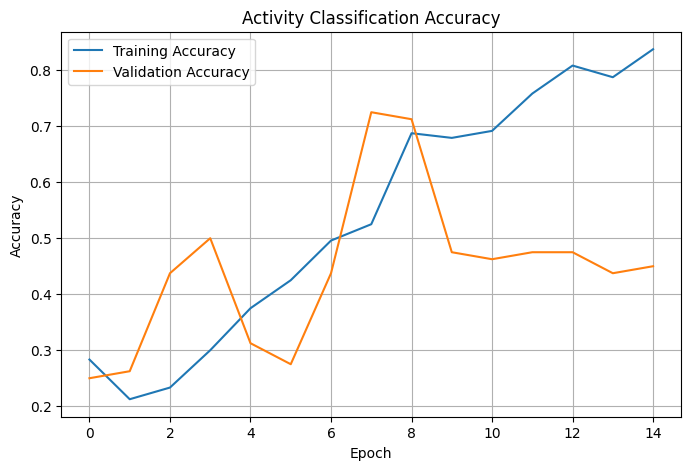

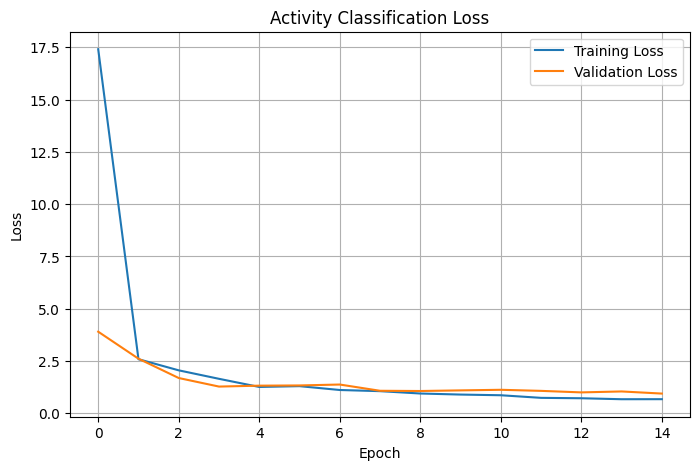


STEP 11F COMPLETED.


In [ ]:
# ============================================================
# STEP 11F
# TRAIN ACTIVITY CLASSIFICATION MODEL
# ESP32-S3 COMPATIBLE
# GOOGLE DRIVE CHECKPOINT
# ============================================================

import os
import tensorflow as tf
import matplotlib.pyplot as plt

print("====================================================")
print("STEP 11F - TRAINING ACTIVITY MODEL")
print("====================================================")

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

EPOCHS = 30

# ------------------------------------------------------------
# MODEL PATH
# ------------------------------------------------------------

MODEL_DIR = os.path.join(
    ACTIVITY_BASE,
    "models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_activity_cnn.keras"
)

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "final_activity_cnn.keras"
)

# ------------------------------------------------------------
# DATA AUGMENTATION
# ------------------------------------------------------------

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomBrightness(
        0.15
    ),

    tf.keras.layers.RandomContrast(
        0.15
    )

])

# ------------------------------------------------------------
# AUGMENT ONLY TRAINING DATA
# ------------------------------------------------------------

def augment_images(images, labels):

    images = tf.cast(
        images,
        tf.float32
    )

    images = data_augmentation(
        images,
        training=True
    )

    return images, labels


train_augmented = train_ds.map(
    augment_images,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_augmented = train_augmented.prefetch(
    tf.data.AUTOTUNE
)

# Validation/test remain unchanged
val_ready = val_ds.prefetch(
    tf.data.AUTOTUNE
)

test_ready = test_ds.prefetch(
    tf.data.AUTOTUNE
)

# ------------------------------------------------------------
# CALLBACKS
# ------------------------------------------------------------

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

print("\nStarting training...")
print("Maximum epochs:", EPOCHS)
print("Best model will be saved to:")
print(BEST_MODEL_PATH)
print()

history = activity_model.fit(

    train_augmented,

    validation_data=val_ready,

    epochs=EPOCHS,

    callbacks=callbacks
)

# ------------------------------------------------------------
# SAVE FINAL MODEL
# ------------------------------------------------------------

activity_model.save(
    FINAL_MODEL_PATH
)

# ------------------------------------------------------------
# BEST RESULTS
# ------------------------------------------------------------

best_val_accuracy = max(
    history.history["val_accuracy"]
)

best_val_loss = min(
    history.history["val_loss"]
)

print("\n====================================================")
print("TRAINING COMPLETED")
print("====================================================")

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print("\nBest model:")
print(BEST_MODEL_PATH)

print("\nFinal model:")
print(FINAL_MODEL_PATH)

# ------------------------------------------------------------
# TRAINING GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Activity Classification Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# LOSS GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Activity Classification Loss"
)

plt.legend()
plt.grid(True)

plt.show()

print("\nSTEP 11F COMPLETED.")

STEP 11G - ACTIVITY MODEL TEST
Loading best model...
Best model loaded successfully.

TEST ACCURACY
Test Accuracy: 31.25%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    STANDING     0.1000    0.2000    0.1333        20
     WALKING     0.0500    0.0500    0.0500        20
     SITTING     1.0000    0.2000    0.3333        20
     FALLING     1.0000    0.8000    0.8889        20

    accuracy                         0.3125        80
   macro avg     0.5375    0.3125    0.3514        80
weighted avg     0.5375    0.3125    0.3514        80


CONFUSION MATRIX
[[ 4 16  0  0]
 [19  1  0  0]
 [16  0  4  0]
 [ 1  3  0 16]]


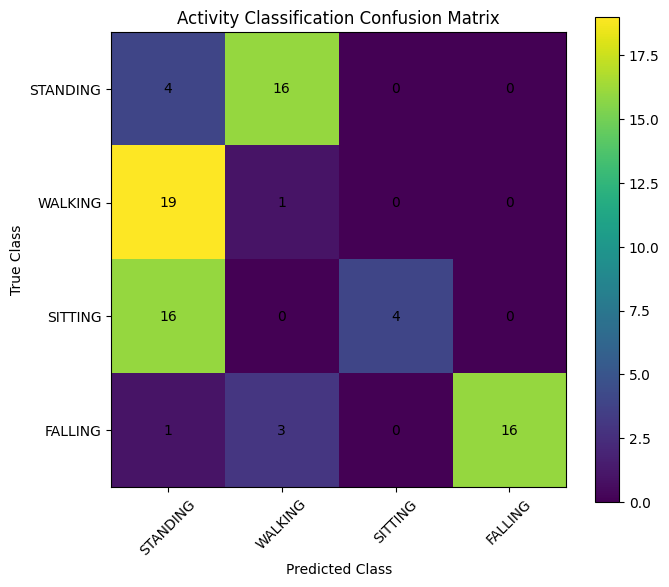


STEP 11G COMPLETED.


In [ ]:
# ============================================================
# STEP 11G
# ACTIVITY MODEL - FINAL TEST
# ============================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("====================================================")
print("STEP 11G - ACTIVITY MODEL TEST")
print("====================================================")

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------

BEST_MODEL_PATH = os.path.join(
    ACTIVITY_BASE,
    "models",
    "best_activity_cnn.keras"
)

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------

print("Loading best model...")

best_activity_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("Best model loaded successfully.")

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_activity_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_classes
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ------------------------------------------------------------
# ACCURACY
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

print("\n====================================================")
print("TEST ACCURACY")
print("====================================================")

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n====================================================")
print("CLASSIFICATION REPORT")
print("====================================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "STANDING",
            "WALKING",
            "SITTING",
            "FALLING"
        ],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n====================================================")
print("CONFUSION MATRIX")
print("====================================================")

print(cm)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Activity Classification Confusion Matrix"
)

plt.colorbar()

classes_display = [
    "STANDING",
    "WALKING",
    "SITTING",
    "FALLING"
]

tick_marks = np.arange(
    len(classes_display)
)

plt.xticks(
    tick_marks,
    classes_display,
    rotation=45
)

plt.yticks(
    tick_marks,
    classes_display
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

print("\nSTEP 11G COMPLETED.")

In [ ]:
# ============================================================
# STEP 11H
# CONVERT ACTIVITY CNN TO FULL INT8 TFLITE
# ============================================================

import os
import numpy as np
import tensorflow as tf

print("====================================================")
print("STEP 11H - INT8 TFLITE CONVERSION")
print("====================================================")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

MODEL_DIR = os.path.join(
    ACTIVITY_BASE,
    "models"
)

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_activity_cnn.keras"
)

TFLITE_PATH = os.path.join(
    MODEL_DIR,
    "activity_int8.tflite"
)

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------

print("Loading best Keras model...")

model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("Model loaded successfully.")

# ------------------------------------------------------------
# REPRESENTATIVE DATASET
# ------------------------------------------------------------

def representative_dataset():

    for images, labels in train_ds.take(50):

        images = tf.cast(
            images,
            tf.float32
        )

        for i in range(
            min(images.shape[0], 32)
        ):

            sample = images[i:i+1]

            yield [
                sample.numpy()
            ]

# ------------------------------------------------------------
# CONVERTER
# ------------------------------------------------------------

print("\nCreating TFLite converter...")

converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

# Full integer quantization
converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = (
    representative_dataset
)

# Force INT8 input/output
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# ------------------------------------------------------------
# CONVERT
# ------------------------------------------------------------

print("Converting to INT8...")

tflite_model = converter.convert()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

with open(
    TFLITE_PATH,
    "wb"
) as f:

    f.write(
        tflite_model
    )

# ------------------------------------------------------------
# SIZE
# ------------------------------------------------------------

model_size_kb = (
    os.path.getsize(
        TFLITE_PATH
    ) / 1024
)

print("\n====================================================")
print("INT8 CONVERSION SUCCESSFUL")
print("====================================================")

print("File:")
print(TFLITE_PATH)

print(
    f"\nModel size: "
    f"{model_size_kb:.2f} KB"
)

print("\nSTEP 11H COMPLETED.")

STEP 11H - INT8 TFLITE CONVERSION
Loading best Keras model...
Model loaded successfully.

Creating TFLite converter...
Converting to INT8...
Saved artifact at '/tmp/tmp7ag027wk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140025693895952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140025693890960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140025693893456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140025693888656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140025531544976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140025531624400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140025531541712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140025531613648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140025531625360:

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



INT8 CONVERSION SUCCESSFUL
File:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/models/activity_int8.tflite

Model size: 33.55 KB

STEP 11H COMPLETED.


In [ ]:
# ============================================================
# STEP 11I
# CHECK TFLITE MODEL COMPATIBILITY
# ============================================================

import os
import tensorflow as tf

print("====================================================")
print("STEP 11I - TFLITE COMPATIBILITY CHECK")
print("====================================================")

TFLITE_PATH = os.path.join(
    ACTIVITY_BASE,
    "models",
    "activity_int8.tflite"
)

# ------------------------------------------------------------
# LOAD INTERPRETER
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=TFLITE_PATH
)

interpreter.allocate_tensors()

# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\n====================================================")
print("INPUT")
print("====================================================")

for detail in input_details:

    print(
        "Name:",
        detail["name"]
    )

    print(
        "Shape:",
        detail["shape"]
    )

    print(
        "Type:",
        detail["dtype"]
    )

    print(
        "Scale:",
        detail["quantization"][0]
    )

    print(
        "Zero point:",
        detail["quantization"][1]
    )

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print("\n====================================================")
print("OUTPUT")
print("====================================================")

for detail in output_details:

    print(
        "Name:",
        detail["name"]
    )

    print(
        "Shape:",
        detail["shape"]
    )

    print(
        "Type:",
        detail["dtype"]
    )

    print(
        "Scale:",
        detail["quantization"][0]
    )

    print(
        "Zero point:",
        detail["quantization"][1]
    )

# ------------------------------------------------------------
# OPERATORS
# ------------------------------------------------------------

print("\n====================================================")
print("TFLITE OPERATORS")
print("====================================================")

try:

    ops = interpreter._get_ops_details()

    unique_ops = []

    for op in ops:

        op_name = op["op_name"]

        if op_name not in unique_ops:
            unique_ops.append(op_name)

    for i, op_name in enumerate(
        unique_ops
    ):

        print(
            f"{i}: {op_name}"
        )

except Exception as e:

    print(
        "Could not list operators:",
        e
    )

# ------------------------------------------------------------
# MODEL SIZE
# ------------------------------------------------------------

size_kb = (
    os.path.getsize(
        TFLITE_PATH
    ) / 1024
)

print("\n====================================================")
print("MODEL SUMMARY")
print("====================================================")

print(
    f"Model size: {size_kb:.2f} KB"
)

print(
    "\nInput:",
    input_details[0]["shape"]
)

print(
    "Input type:",
    input_details[0]["dtype"]
)

print(
    "Output:",
    output_details[0]["shape"]
)

print(
    "Output type:",
    output_details[0]["dtype"]
)

print("\nSTEP 11I COMPLETED.")

STEP 11I - TFLITE COMPATIBILITY CHECK

INPUT
Name: serving_default_input_layer:0
Shape: [ 1 96 96  3]
Type: <class 'numpy.int8'>
Scale: 1.0
Zero point: -128

OUTPUT
Name: StatefulPartitionedCall_1:0
Shape: [1 4]
Type: <class 'numpy.int8'>
Scale: 0.00390625
Zero point: -128

TFLITE OPERATORS
0: CONV_2D
1: MAX_POOL_2D
2: MEAN
3: FULLY_CONNECTED
4: SOFTMAX
5: DELEGATE

MODEL SUMMARY
Model size: 33.55 KB

Input: [ 1 96 96  3]
Input type: <class 'numpy.int8'>
Output: [1 4]
Output type: <class 'numpy.int8'>

STEP 11I COMPLETED.


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ============================================================
# STEP 11J
# GENERATE ARDUINO HEADER FOR ACTIVITY MODEL
# ============================================================

import os

print("====================================================")
print("STEP 11J - GENERATING ARDUINO HEADER")
print("====================================================")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

MODEL_DIR = os.path.join(
    ACTIVITY_BASE,
    "models"
)

TFLITE_PATH = os.path.join(
    MODEL_DIR,
    "activity_int8.tflite"
)

HEADER_PATH = os.path.join(
    MODEL_DIR,
    "activity_int8_model_data.h"
)

# ------------------------------------------------------------
# CHECK MODEL
# ------------------------------------------------------------

if not os.path.exists(TFLITE_PATH):

    raise FileNotFoundError(
        "activity_int8.tflite was not found."
    )

# ------------------------------------------------------------
# READ MODEL
# ------------------------------------------------------------

with open(
    TFLITE_PATH,
    "rb"
) as f:

    model_data = f.read()

print(
    "TFLite model size:",
    len(model_data),
    "bytes"
)

# ------------------------------------------------------------
# GENERATE C HEADER
# ------------------------------------------------------------

with open(
    HEADER_PATH,
    "w"
) as f:

    f.write(
        "// =====================================================\n"
    )

    f.write(
        "// ESP32-S3 ACTIVITY CLASSIFICATION MODEL\n"
    )

    f.write(
        "// INT8 TensorFlow Lite Micro Model\n"
    )

    f.write(
        "// Auto-generated - DO NOT EDIT\n"
    )

    f.write(
        "// =====================================================\n\n"
    )

    f.write(
        "#ifndef ACTIVITY_INT8_MODEL_DATA_H\n"
    )

    f.write(
        "#define ACTIVITY_INT8_MODEL_DATA_H\n\n"
    )

    f.write(
        "#include <stdint.h>\n\n"
    )

    f.write(
        "alignas(8) const unsigned char "
        "g_activity_int8_model[] = {\n"
    )

    # Write bytes in groups
    for i in range(
        0,
        len(model_data),
        12
    ):

        chunk = model_data[
            i:i+12
        ]

        line = ", ".join(
            f"0x{byte:02x}"
            for byte in chunk
        )

        f.write(
            "    " + line + ",\n"
        )

    f.write(
        "};\n\n"
    )

    f.write(
        "const unsigned int "
        "g_activity_int8_model_len = "
        f"{len(model_data)};\n\n"
    )

    f.write(
        "#endif\n"
    )

# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("\n====================================================")
print("ARDUINO HEADER CREATED")
print("====================================================")

print("Header:")
print(HEADER_PATH)

print(
    "\nModel variable:"
)

print(
    "g_activity_int8_model"
)

print(
    "\nModel length variable:"
)

print(
    "g_activity_int8_model_len"
)

print(
    "\nHeader size:",
    os.path.getsize(HEADER_PATH),
    "bytes"
)

print("\nSTEP 11J COMPLETED.")

STEP 11J - GENERATING ARDUINO HEADER
TFLite model size: 34360 bytes

ARDUINO HEADER CREATED
Header:
/content/drive/MyDrive/ESP32S3_EdgeAI_Smart_Security/activity_ai_project/models/activity_int8_model_data.h

Model variable:
g_activity_int8_model

Model length variable:
g_activity_int8_model_len

Header size: 218058 bytes

STEP 11J COMPLETED.


In [ ]:
# ============================================================
# STEP 11K
# DOWNLOAD ACTIVITY MODEL HEADER
# ============================================================

from google.colab import files

print("====================================================")
print("STEP 11K - DOWNLOAD ARDUINO HEADER")
print("====================================================")

files.download(
    HEADER_PATH
)

print("\nDownload initiated.")
print("File:")
print("activity_int8_model_data.h")

STEP 11K - DOWNLOAD ARDUINO HEADER


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download initiated.
File:
activity_int8_model_data.h
